# Laguna XS.2 v9 — Matched-Budget PEFT Benchmark

## Does **where we write** matter more than **how we parameterize the update**?

This notebook is the post-v8 decisive benchmark. It uses **official GSM8K** as the target capability and **official MBPP** as a held-out control domain, then compares eight post-training strategies under a matched trainable-parameter budget.

**Final methods:** random experts, routing experts, causal experts, raw-gradient experts, gradient-specific experts, standard broad attention LoRA, random-layer attention LoRA, and gradient-guided attention LoRA (layers chosen by direct attention-gradient measurement).

**Default budget:** K=4 full Laguna routed experts = 12,582,912 trainable parameters. LoRA ranks are chosen from the model's actual attention shapes to match this budget within 5% and then verified from actual `requires_grad` parameters after adapter injection.

**Leakage rule:** selection data chooses locations; validation chooses one shared LoRA LR; every selector/budget/LR is frozen to disk before untouched GSM8K/MBPP final evaluation begins.

Optimized for the same AWS `g7e.2xlarge` / RTX PRO 6000 96GB setup. Direct BF16 Transformers load only. **No vLLM.**

## 1 — Install dependencies once

In [2]:
# Keep the CUDA-enabled PyTorch build supplied by the AWS image.
# Run this cell once, restart the kernel once, then Run All.
%pip -q install \
  "transformers==5.14.1" \
  "peft==0.19.1" \
  "datasets>=4.0,<5" \
  "accelerate>=1.10.0" \
  "huggingface_hub>=0.35.0" \
  safetensors pandas numpy psutil tqdm matplotlib packaging tabulate

print("Dependencies installed. Restart the kernel once if packages changed.")

Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Restart the kernel once if packages changed.


## 2 — Runtime tuning for g7e.2xlarge

In [3]:
import os

os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["NUMEXPR_NUM_THREADS"] = "6"
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["MALLOC_ARENA_MAX"] = "4"

os.environ["HF_ENABLE_PARALLEL_LOADING"] = "true"
os.environ["HF_PARALLEL_LOADING_WORKERS"] = "2"
os.environ["HF_XET_NUM_CONCURRENT_RANGE_GETS"] = "8"
os.environ["HF_XET_CHUNK_CACHE_SIZE_BYTES"] = "0"

os.environ["CUDA_MODULE_LOADING"] = "LAZY"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True,max_split_size_mb:512"
)

print("Runtime configured for AWS g7e.2xlarge / v9.")

Runtime configured for AWS g7e.2xlarge / v9.


## 3 — Canonical imports

In [4]:
import os
import gc
import json
import math
import time
import types
import shutil
import hashlib
import platform
import sys
import importlib.util
import re
import uuid
import zipfile

from pathlib import Path
from contextlib import contextmanager, ExitStack
from datetime import datetime, timezone
from decimal import Decimal, InvalidOperation
from fractions import Fraction

import numpy as np
import pandas as pd
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

print("Core imports: PASS")
print("Torch:", torch.__version__)

/home/ec2-user/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Core imports: PASS
Torch: 2.13.0+cu130


## 4 — Dependency verification

In [5]:
from importlib.metadata import version as package_version
from packaging.version import Version

required_modules = [
    "torch", "transformers", "peft", "datasets", "accelerate",
    "huggingface_hub", "safetensors", "numpy", "pandas", "psutil",
    "tqdm", "matplotlib", "tabulate",
]
missing = [x for x in required_modules if importlib.util.find_spec(x) is None]
if missing:
    raise ModuleNotFoundError(
        "Missing required modules: " + ", ".join(missing)
        + ". Re-run the install cell, restart, then Run All."
    )

transformers_version = package_version("transformers")
peft_version = package_version("peft")

if transformers_version != "5.14.1":
    raise RuntimeError(
        f"Requires transformers==5.14.1; found {transformers_version}."
    )
if Version(peft_version) < Version("0.19.1"):
    raise RuntimeError(
        f"Transformers v5 PEFT integration requires peft>=0.19.1; found {peft_version}."
    )
if importlib.util.find_spec("transformers.conversion_mapping") is None:
    raise ModuleNotFoundError("transformers.conversion_mapping unavailable.")

print("Dependency verification: PASS")
print("Transformers:", transformers_version)
print("PEFT:", peft_version)
print("Datasets:", package_version("datasets"))

Dependency verification: PASS
Transformers: 5.14.1
PEFT: 0.19.1
Datasets: 4.8.5


## 5 — Hardware and storage preflight

In [6]:
import os
import shutil
import platform
from pathlib import Path

import psutil
import torch

ram = psutil.virtual_memory()

print("=== Host ===")
print("Python:", platform.python_version())
print("Logical CPUs:", os.cpu_count())
print(f"RAM total:     {ram.total/2**30:.2f} GiB")
print(f"RAM available: {ram.available/2**30:.2f} GiB")

print("\n=== CUDA ===")
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not visible.")

if torch.cuda.device_count() != 1:
    raise RuntimeError(
        f"This notebook expects exactly one GPU; found {torch.cuda.device_count()}."
    )

props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print(f"VRAM: {props.total_memory/2**30:.2f} GiB")
print("Compute capability:", torch.cuda.get_device_capability(0))

if props.total_memory / 2**30 < 88:
    raise RuntimeError("Need a 96GB-class GPU (~89 GiB binary or larger).")

if (os.cpu_count() or 0) < 8:
    print("WARNING: fewer than 8 logical CPUs detected.")

if ram.total / 2**30 < 58:
    print("WARNING: less than a 64-GiB-class host detected.")

roots = [
    Path("/home/ec2-user/workspace"),
    Path("/workspace"),
    Path("/mnt/data"),
    Path("/root"),
    Path("/tmp"),
    Path.cwd(),
]

choices = []
seen_devices = set()

for p in roots:
    try:
        if not p.exists() or not os.access(p, os.W_OK):
            continue
        dev = os.stat(p).st_dev
        if dev in seen_devices:
            continue
        seen_devices.add(dev)
        usage = shutil.disk_usage(p)
        choices.append((usage.free, p, usage))
    except OSError:
        pass

if not choices:
    raise RuntimeError("No writable filesystem found.")

_, WORK_ROOT, disk = max(choices, key=lambda x: x[0])

print("\n=== Storage ===")
print("Work root:", WORK_ROOT)
print(f"Disk free: {disk.free/2**30:.2f} GiB")
print("Hardware preflight: PASS")

=== Host ===
Python: 3.10.12
Logical CPUs: 8
RAM total:     62.27 GiB
RAM available: 60.73 GiB

=== CUDA ===
Torch: 2.13.0+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 94.97 GiB
Compute capability: (12, 0)

=== Storage ===
Work root: /home/ec2-user/workspace
Disk free: 916.04 GiB
Hardware preflight: PASS


## 6 — Experiment configuration

In [7]:
TARGET_DATASET_ID = "openai/gsm8k"
TARGET_DATASET_CONFIG = "main"
# Official GSM8K parquet-conversion commit, frozen for reproducibility.
TARGET_DATASET_REVISION = "e53f048856ff4f594e959d75785d2c2d37b678ee"

CONTROL_DATASET_ID = "google-research-datasets/mbpp"
CONTROL_DATASET_CONFIG = "full"
# Optional explicit pin if desired on AWS; the frozen local snapshot is hashed either way.
CONTROL_DATASET_REVISION = os.environ.get("MBPP_REVISION") or "4bb6404fdc6cacfda99d4ac4205087b89d32030c"

DATA_SPLIT_SEED = 93017
SELECTION_TARGET_N = 32
SELECTION_CONTROL_N = 32
TRAIN_TARGET_N = 256
VALIDATION_TARGET_N = 64
VALIDATION_CONTROL_N = 64
FINAL_TARGET_N = 128
FINAL_CONTROL_N = 128
GENERATION_EVAL_N = 128

CONTROL_PENALTY = 0.75
GLOBAL_GRAD_PROBE_CASES = 12
GLOBAL_GRAD_CHUNK = 8
PRECISE_GRAD_CASES = 12
ATTENTION_GRAD_PROBE_CASES = 12
SELECTOR_TOP_N = 16

CAUSAL_TOP_LAYERS = 8
CAUSAL_SEARCH_SEEDS = [17, 53, 101, 211]
CAUSAL_INITIAL_GROUP_SIZE = 32
CAUSAL_BEAM_WIDTH = 4
CAUSAL_COALITION_POOL = 20

EXPERT_BUDGET_K = 4
RANKING_MAX_K = 8
# v8 causal helper uses this global; final v9 matched experiment uses K=4.
BUDGET_KS = [1, 2, 4]

GUIDED_LORA_N_LAYERS = 8
RANDOM_LORA_N_LAYERS = 8
RANDOM_EXPERT_SEED = 93201
RANDOM_LAYER_SEED = 93202
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
MAX_LORA_BUDGET_REL_ERROR = 0.05

EXPERT_LR = 1e-5

# Shared optimizer geometry for BOTH full-expert and LoRA arms.
OPTIMIZER_BETAS = (0.9, 0.95)
OPTIMIZER_WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0

# Conventional LoRA scaling: alpha == rank.
LORA_ALPHA_MULTIPLIER = 1.0
# Standard broad LoRA alone tunes LR; frozen winner is shared by all LoRA location arms.
LORA_LR_GRID = [5e-5, 1e-4, 2e-4]
LR_SWEEP_SEED = 101
TRAIN_EPOCHS = 2
TRAIN_MAX_UPDATES = 64
TRAIN_GRAD_ACCUM = 8
FINAL_ORDER_SEEDS = [11, 23, 47]

EVAL_BATCH_SIZE = 8
GENERATION_BATCH_SIZE = 4
GENERATION_MAX_NEW_TOKENS = 256
DELTA_MERGE_WARN_NLL = 0.05

PROTOCOL_VERSION = "v9.0-matched-peft-gsm8k"
RESULTS_ROOT = WORK_ROOT / "laguna_xs2_v9_matched_peft_gsm8k"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS = RESULTS_ROOT
CURRENT_CAPABILITY = "gsm8k"

print("Results root:", RESULTS_ROOT)
print("Protocol:", PROTOCOL_VERSION)

Results root: /home/ec2-user/workspace/laguna_xs2_v9_matched_peft_gsm8k
Protocol: v9.0-matched-peft-gsm8k


## 7 — Crash-safe checkpoint helpers

In [8]:
def atomic_to_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    df.to_csv(tmp, index=index)
    with open(tmp, "rb") as f:
        os.fsync(f.fileno())
    os.replace(tmp, path)


def atomic_write_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        f.write(text)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)


def read_checkpoint_csv(path, required_columns=None, dedupe_keys=None):
    path = Path(path)
    required_columns = list(required_columns or [])
    if not path.exists():
        return pd.DataFrame(columns=required_columns)
    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=required_columns)
    missing = set(required_columns) - set(df.columns)
    if missing:
        raise RuntimeError(
            f"Checkpoint {path} has incompatible schema; missing {sorted(missing)}"
        )
    if dedupe_keys and not df.empty:
        missing_keys = set(dedupe_keys) - set(df.columns)
        if missing_keys:
            raise RuntimeError(
                f"Checkpoint {path} missing dedupe keys {sorted(missing_keys)}"
            )
        df = df.drop_duplicates(list(dedupe_keys), keep="last").reset_index(drop=True)
    return df


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def stable_hash_order(df, key_col, salt):
    out = df.copy()
    out["_stable_hash"] = out[key_col].astype(str).map(
        lambda x: hashlib.sha256((str(salt) + "\\0" + x).encode("utf-8")).hexdigest()
    )
    return out.sort_values("_stable_hash").drop(columns=["_stable_hash"]).reset_index(drop=True)

## 8 — Acquire and freeze official benchmark rows

In [9]:
from datasets import load_dataset

SNAPSHOT_CSV = RESULTS / "benchmark_snapshot.csv"
SNAPSHOT_MANIFEST = RESULTS / "benchmark_snapshot_manifest.json"


def gsm8k_prompt(question):
    return (
        "Solve the following math problem. Show your reasoning, then end with "
        "a final line exactly in the form '#### <answer>'.\\n\\nProblem: "
        + str(question).strip()
    )


def mbpp_prompt(text):
    return (
        "Write Python code that solves the following task. Return only the code.\\n\\nTask: "
        + str(text).strip()
    )


def build_benchmark_snapshot():
    print("Loading GSM8K...")
    gsm = load_dataset(
        TARGET_DATASET_ID,
        TARGET_DATASET_CONFIG,
        revision=TARGET_DATASET_REVISION,
    )
    if not {"train", "test"}.issubset(gsm.keys()):
        raise RuntimeError("GSM8K train/test splits missing.")
    gsm_train = pd.DataFrame(gsm["train"])
    gsm_test = pd.DataFrame(gsm["test"])
    if not {"question", "answer"}.issubset(gsm_train.columns):
        raise RuntimeError("GSM8K question/answer columns missing.")

    gsm_train = stable_hash_order(gsm_train, "question", f"gsm_train_{DATA_SPLIT_SEED}")
    gsm_test = stable_hash_order(gsm_test, "question", f"gsm_test_{DATA_SPLIT_SEED}")

    needed = SELECTION_TARGET_N + TRAIN_TARGET_N + VALIDATION_TARGET_N
    if len(gsm_train) < needed or len(gsm_test) < FINAL_TARGET_N:
        raise RuntimeError("Insufficient GSM8K rows for requested protocol.")

    a = 0
    gsm_selection = gsm_train.iloc[a:a+SELECTION_TARGET_N].copy(); a += SELECTION_TARGET_N
    gsm_fit = gsm_train.iloc[a:a+TRAIN_TARGET_N].copy(); a += TRAIN_TARGET_N
    gsm_validation = gsm_train.iloc[a:a+VALIDATION_TARGET_N].copy()
    gsm_final = gsm_test.iloc[:FINAL_TARGET_N].copy()

    print("Loading MBPP...")
    mbpp_kwargs = {}
    if CONTROL_DATASET_REVISION:
        mbpp_kwargs["revision"] = CONTROL_DATASET_REVISION
    mbpp = load_dataset(CONTROL_DATASET_ID, CONTROL_DATASET_CONFIG, **mbpp_kwargs)
    if not {"train", "validation", "test"}.issubset(mbpp.keys()):
        raise RuntimeError(
            "Expected official MBPP full config with train/validation/test splits."
        )
    mbpp_train = pd.DataFrame(mbpp["train"])
    mbpp_validation = pd.DataFrame(mbpp["validation"])
    mbpp_test = pd.DataFrame(mbpp["test"])

    for name, part in [("train", mbpp_train), ("validation", mbpp_validation), ("test", mbpp_test)]:
        if not {"task_id", "text", "code"}.issubset(part.columns):
            raise RuntimeError(f"MBPP {name} missing task_id/text/code columns.")

    mbpp_train = stable_hash_order(mbpp_train, "task_id", f"mbpp_train_{DATA_SPLIT_SEED}")
    mbpp_validation = stable_hash_order(mbpp_validation, "task_id", f"mbpp_val_{DATA_SPLIT_SEED}")
    mbpp_test = stable_hash_order(mbpp_test, "task_id", f"mbpp_test_{DATA_SPLIT_SEED}")

    if len(mbpp_train) < SELECTION_CONTROL_N:
        raise RuntimeError("Insufficient MBPP train controls.")
    if len(mbpp_validation) < VALIDATION_CONTROL_N:
        raise RuntimeError("Insufficient MBPP validation controls.")
    if len(mbpp_test) < FINAL_CONTROL_N:
        raise RuntimeError("Insufficient MBPP test controls.")

    rows = []

    def add_gsm(part, split):
        for r in part.itertuples(index=False):
            q = str(r.question).strip()
            answer = str(r.answer).strip()
            rows.append({
                "example_id": "gsm8k_" + hashlib.sha256(q.encode("utf-8")).hexdigest()[:16],
                "split": split,
                "kind": "target",
                "source": TARGET_DATASET_ID,
                "prompt": gsm8k_prompt(q),
                "reference": answer,
                "gold_answer": answer.split("####")[-1].strip(),
            })

    add_gsm(gsm_selection, "selection")
    add_gsm(gsm_fit, "train")
    add_gsm(gsm_validation, "validation")
    add_gsm(gsm_final, "final")

    def add_mbpp(part, split):
        for r in part.itertuples(index=False):
            rows.append({
                "example_id": f"mbpp_{int(r.task_id)}",
                "split": split,
                "kind": "control",
                "source": CONTROL_DATASET_ID,
                "prompt": mbpp_prompt(r.text),
                "reference": str(r.code).replace("\\r\\n", "\\n").replace("\\r", "\\n").strip(),
                "gold_answer": "",
            })

    add_mbpp(mbpp_train.iloc[:SELECTION_CONTROL_N], "selection")
    add_mbpp(mbpp_validation.iloc[:VALIDATION_CONTROL_N], "validation")
    add_mbpp(mbpp_test.iloc[:FINAL_CONTROL_N], "final")

    return pd.DataFrame(rows)


if SNAPSHOT_CSV.exists():
    benchmark_df = pd.read_csv(SNAPSHOT_CSV)
    print("Reusing frozen snapshot:", SNAPSHOT_CSV)
else:
    benchmark_df = build_benchmark_snapshot()
    atomic_to_csv(benchmark_df, SNAPSHOT_CSV, index=False)

required_cols = {"example_id", "split", "kind", "source", "prompt", "reference", "gold_answer"}
missing = required_cols - set(benchmark_df.columns)
if missing:
    raise RuntimeError(f"Snapshot missing columns: {sorted(missing)}")
benchmark_df["gold_answer"] = benchmark_df["gold_answer"].fillna("").astype(str)

expected_counts = {
    ("selection", "target"): SELECTION_TARGET_N,
    ("selection", "control"): SELECTION_CONTROL_N,
    ("train", "target"): TRAIN_TARGET_N,
    ("validation", "target"): VALIDATION_TARGET_N,
    ("validation", "control"): VALIDATION_CONTROL_N,
    ("final", "target"): FINAL_TARGET_N,
    ("final", "control"): FINAL_CONTROL_N,
}
actual_counts = benchmark_df.groupby(["split", "kind"]).size().to_dict()
for key, expected in expected_counts.items():
    if int(actual_counts.get(key, 0)) != int(expected):
        raise RuntimeError(f"Snapshot count mismatch {key}: {actual_counts.get(key,0)} != {expected}")

if benchmark_df["example_id"].duplicated().any():
    raise RuntimeError("Duplicate benchmark example IDs.")
if benchmark_df[["prompt", "reference"]].isna().any().any():
    raise RuntimeError("Null prompt/reference in benchmark snapshot.")
if benchmark_df[benchmark_df.kind == "target"]["prompt"].duplicated().any():
    raise RuntimeError("GSM8K prompt leakage across protocol splits.")
if benchmark_df[benchmark_df.kind == "control"]["example_id"].duplicated().any():
    raise RuntimeError("MBPP task leakage across protocol splits.")

SNAPSHOT_SHA256 = sha256_file(SNAPSHOT_CSV)
manifest = {
    "target_dataset_id": TARGET_DATASET_ID,
    "target_dataset_config": TARGET_DATASET_CONFIG,
    "target_dataset_revision": TARGET_DATASET_REVISION,
    "control_dataset_id": CONTROL_DATASET_ID,
    "control_dataset_config": CONTROL_DATASET_CONFIG,
    "control_dataset_revision": CONTROL_DATASET_REVISION,
    "snapshot_csv": str(SNAPSHOT_CSV),
    "snapshot_sha256": SNAPSHOT_SHA256,
    "counts": {f"{k[0]}:{k[1]}": int(v) for k,v in expected_counts.items()},
}
atomic_write_text(SNAPSHOT_MANIFEST, json.dumps(manifest, indent=2))

print("Benchmark snapshot validation: PASS")
print("Snapshot SHA256:", SNAPSHOT_SHA256)
display(benchmark_df.groupby(["split", "kind", "source"]).size().rename("n").reset_index())

Loading GSM8K...


Generating test split: 100%|████| 1319/1319 [00:00<00:00, 541478.61 examples/s]


Loading MBPP...


Generating prompt split: 100%|████████| 10/10 [00:00<00:00, 5741.69 examples/s]

Benchmark snapshot validation: PASS
Snapshot SHA256: 8cedb762f6d18ef0dc2f3a828bae64d68da03643238aa2659d93a65a289e361b


,split,kind,source,n
0,final,control,google-research-datasets/mbpp,128
1,final,target,openai/gsm8k,128
2,selection,control,google-research-datasets/mbpp,32
3,selection,target,openai/gsm8k,32
4,train,target,openai/gsm8k,256
5,validation,control,google-research-datasets/mbpp,64
6,validation,target,openai/gsm8k,64


## 9 — Freeze protocol fingerprint

In [10]:
PROTOCOL_CONFIG = {
    "protocol_version": PROTOCOL_VERSION,
    "model_id": "poolside/Laguna-XS.2",
    "snapshot_sha256": SNAPSHOT_SHA256,
    "target_dataset_id": TARGET_DATASET_ID,
    "target_dataset_config": TARGET_DATASET_CONFIG,
    "target_dataset_revision": TARGET_DATASET_REVISION,
    "control_dataset_id": CONTROL_DATASET_ID,
    "control_dataset_config": CONTROL_DATASET_CONFIG,
    "control_dataset_revision": CONTROL_DATASET_REVISION,
    "data_split_seed": DATA_SPLIT_SEED,
    "selection_target_n": SELECTION_TARGET_N,
    "selection_control_n": SELECTION_CONTROL_N,
    "train_target_n": TRAIN_TARGET_N,
    "validation_target_n": VALIDATION_TARGET_N,
    "validation_control_n": VALIDATION_CONTROL_N,
    "final_target_n": FINAL_TARGET_N,
    "final_control_n": FINAL_CONTROL_N,
    "generation_eval_n": GENERATION_EVAL_N,
    "control_penalty": CONTROL_PENALTY,
    "global_grad_probe_cases": GLOBAL_GRAD_PROBE_CASES,
    "precise_grad_cases": PRECISE_GRAD_CASES,
    "attention_grad_probe_cases": ATTENTION_GRAD_PROBE_CASES,
    "selector_top_n": SELECTOR_TOP_N,
    "causal_top_layers": CAUSAL_TOP_LAYERS,
    "causal_search_seeds": CAUSAL_SEARCH_SEEDS,
    "causal_initial_group_size": CAUSAL_INITIAL_GROUP_SIZE,
    "causal_beam_width": CAUSAL_BEAM_WIDTH,
    "causal_coalition_pool": CAUSAL_COALITION_POOL,
    "expert_budget_k": EXPERT_BUDGET_K,
    "guided_lora_n_layers": GUIDED_LORA_N_LAYERS,
    "random_lora_n_layers": RANDOM_LORA_N_LAYERS,
    "lora_target_modules": LORA_TARGET_MODULES,
    "expert_lr": EXPERT_LR,
    "random_expert_seed": RANDOM_EXPERT_SEED,
    "random_layer_seed": RANDOM_LAYER_SEED,
    "ranking_max_k": RANKING_MAX_K,
    "budget_ks": BUDGET_KS,
    "max_lora_budget_rel_error": MAX_LORA_BUDGET_REL_ERROR,
    "optimizer_betas": OPTIMIZER_BETAS,
    "optimizer_weight_decay": OPTIMIZER_WEIGHT_DECAY,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "lora_alpha_multiplier": LORA_ALPHA_MULTIPLIER,
    "lora_lr_grid": LORA_LR_GRID,
    "lr_sweep_seed": LR_SWEEP_SEED,
    "train_epochs": TRAIN_EPOCHS,
    "train_max_updates": TRAIN_MAX_UPDATES,
    "train_grad_accum": TRAIN_GRAD_ACCUM,
    "final_order_seeds": FINAL_ORDER_SEEDS,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "generation_batch_size": GENERATION_BATCH_SIZE,
    "generation_max_new_tokens": GENERATION_MAX_NEW_TOKENS,
}
PROTOCOL_HASH = hashlib.sha256(
    json.dumps(PROTOCOL_CONFIG, sort_keys=True).encode("utf-8")
).hexdigest()[:16]
protocol_path = RESULTS / "protocol_config.json"
payload = {"protocol_hash": PROTOCOL_HASH, "protocol_config": PROTOCOL_CONFIG}
if protocol_path.exists():
    existing = json.loads(protocol_path.read_text())
    if existing.get("protocol_hash") != PROTOCOL_HASH:
        raise RuntimeError(
            "Existing v9 result root has a different protocol hash. Use a fresh RESULTS_ROOT."
        )
else:
    atomic_write_text(protocol_path, json.dumps(payload, indent=2))
print("Protocol hash:", PROTOCOL_HASH)

Protocol hash: 792fd9d4a19c5f37


## 10 — Resolve official BF16 Laguna XS.2 checkpoint

In [11]:
from huggingface_hub import snapshot_download

MODEL_ID = "poolside/Laguna-XS.2"

default_model_path = (
    Path("/home/ec2-user/workspace/models/Laguna-XS.2")
    if Path("/home/ec2-user/workspace").exists()
    else WORK_ROOT / "models" / "Laguna-XS.2"
)

MODEL_PATH = Path(
    os.environ.get("LAGUNA_BF16_PATH", str(default_model_path))
).expanduser().resolve()

EXPECTED_SHARDS = [
    f"model-{i:05d}-of-00014.safetensors"
    for i in range(1, 15)
]

complete = (
    (MODEL_PATH / "config.json").exists()
    and all((MODEL_PATH / x).exists() for x in EXPECTED_SHARDS)
)

if not complete:
    MODEL_PATH.mkdir(parents=True, exist_ok=True)

    free_gib = shutil.disk_usage(MODEL_PATH).free / 2**30

    if free_gib < 85:
        raise RuntimeError(
            f"Need ~85 GiB free for a fresh BF16 download; found {free_gib:.1f} GiB."
        )

    print("Downloading Laguna XS.2 BF16...")
    snapshot_download(
        repo_id=MODEL_ID,
        local_dir=str(MODEL_PATH),
        allow_patterns=[
            "*.safetensors",
            "*.json",
            "*.py",
            "*.jinja",
            "LICENSE*",
            "README*",
        ],
        max_workers=2,
    )

missing = [x for x in EXPECTED_SHARDS if not (MODEL_PATH / x).exists()]

if missing:
    raise RuntimeError(f"Incomplete checkpoint; missing: {missing}")

sizes = [(x, (MODEL_PATH / x).stat().st_size) for x in EXPECTED_SHARDS]

print("MODEL_PATH:", MODEL_PATH)
print(f"14-shard payload: {sum(n for _, n in sizes)/1e9:.3f} GB")
print("Checkpoint verification: PASS")

MODEL_PATH: /home/ec2-user/workspace/models/Laguna-XS.2
14-shard payload: 66.889 GB
Checkpoint verification: PASS


## 11 — Register Laguna checkpoint conversion mapping

In [12]:
from transformers.conversion_mapping import (
    get_checkpoint_conversion_mapping,
    register_checkpoint_conversion_mapping,
    USER_REGISTERED_MAPPINGS,
)

laguna_mapping = get_checkpoint_conversion_mapping("laguna")

if laguna_mapping is None:
    raise RuntimeError(
        "Transformers does not expose the native Laguna checkpoint conversion mapping."
    )

register_checkpoint_conversion_mapping(
    "laguna",
    laguna_mapping,
    overwrite=True,
)

if "laguna" not in USER_REGISTERED_MAPPINGS:
    raise RuntimeError("Laguna conversion mapping registration failed.")

print("Laguna checkpoint conversion mapping: REGISTERED")
print("Conversion operations:", len(laguna_mapping))

Laguna checkpoint conversion mapping: REGISTERED
Conversion operations: 4


## 12 — Load BF16 model directly onto RTX PRO 6000

In [13]:
import gc
import time
import torch
import transformers

from transformers import AutoTokenizer, AutoModelForCausalLM

torch.set_num_threads(min(6, os.cpu_count() or 6))

try:
    torch.set_num_interop_threads(2)
except RuntimeError:
    pass

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("Transformers:", transformers.__version__)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    fix_mistral_regex=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

t0 = time.time()

model, loading_info = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    device_map={"": 0},
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_safetensors=True,
    attn_implementation="sdpa",
    output_loading_info=True,
)

model.eval()
model.config.use_cache = False

for p in model.parameters():
    p.requires_grad_(False)

missing = list(loading_info.get("missing_keys", []))
unexpected = list(loading_info.get("unexpected_keys", []))
mismatched = list(loading_info.get("mismatched_keys", []))

critical = [
    k for k in (missing + unexpected)
    if (
        ".mlp.experts" in k
        or ".mlp.gate" in k
        or "e_score_correction_bias" in k
    )
]

if critical or mismatched:
    raise RuntimeError(
        "Critical checkpoint mismatch.\n"
        f"critical sample: {critical[:12]}\n"
        f"mismatched sample: {mismatched[:12]}"
    )

del loading_info
gc.collect()
torch.cuda.synchronize()

free_b, total_b = torch.cuda.mem_get_info()

print(f"Loaded in {(time.time()-t0)/60:.2f} min")
print(f"GPU allocated: {torch.cuda.memory_allocated()/2**30:.2f} GiB")
print(f"GPU reserved:  {torch.cuda.memory_reserved()/2**30:.2f} GiB")
print(f"GPU peak:      {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")
print(f"Driver free:   {free_b/2**30:.2f} GiB")
print(f"Host RAM available: {psutil.virtual_memory().available/2**30:.2f} GiB")
if hasattr(
    model,
    "get_experts_implementation",
):
    try:
        print(
            "Experts backend:",
            model.get_experts_implementation(),
        )
    except Exception as exc:
        print(
            "Experts backend query unavailable:",
            repr(
                exc
            ),
        )

if any(
    p.requires_grad
    for p in model.parameters()
):
    raise RuntimeError(
        "Base model unexpectedly has trainable parameters after load."
    )

print("BF16 load: PASS")

Transformers: 5.14.1


Loading weights: 100%|███████████████████████| 639/639 [08:28<00:00,  1.26it/s]


Loaded in 8.53 min
GPU allocated: 62.29 GiB
GPU reserved:  70.11 GiB
GPU peak:      63.29 GiB
Driver free:   24.32 GiB
Host RAM available: 58.68 GiB
Experts backend: {'': 'grouped_mm'}
BF16 load: PASS


## 13 — Validate Laguna MoE architecture

In [14]:
cfg = model.config

SPARSE_LAYERS = []

for idx, layer in enumerate(model.model.layers):
    mlp = getattr(layer, "mlp", None)

    if (
        mlp is not None
        and hasattr(mlp, "gate")
        and hasattr(mlp, "experts")
        and hasattr(mlp.experts, "gate_up_proj")
        and hasattr(mlp.experts, "down_proj")
    ):
        SPARSE_LAYERS.append(idx)

assert cfg.hidden_size == 2048
assert cfg.num_hidden_layers == 40
assert cfg.num_experts == 256
assert cfg.num_experts_per_tok == 8
assert cfg.moe_intermediate_size == 512
assert len(SPARSE_LAYERS) == 39

sample_mlp = model.model.layers[SPARSE_LAYERS[0]].mlp

assert tuple(sample_mlp.experts.gate_up_proj.shape) == (256, 1024, 2048)
assert tuple(sample_mlp.experts.down_proj.shape) == (256, 2048, 512)

params_per_expert = (
    sample_mlp.experts.gate_up_proj[0].numel()
    + sample_mlp.experts.down_proj[0].numel()
)

print("Sparse layers:", SPARSE_LAYERS)
print(f"Params / expert: {params_per_expert:,} ({params_per_expert/1e6:.3f}M)")
print("Architecture validation: PASS")

Sparse layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Params / expert: 3,145,728 (3.146M)
Architecture validation: PASS


## 14 — PEFT integration preflight

In [15]:
from peft import LoraConfig, TaskType
if not hasattr(model, "add_adapter") or not hasattr(model, "delete_adapter"):
    raise RuntimeError("Transformers PEFT adapter integration unavailable.")
for p in model.parameters():
    p.requires_grad_(False)
print("PEFT integration import: PASS")

PEFT integration import: PASS


## 15 — Correct Laguna teacher forcing

In [16]:
def chat_prefix_text(prompt):
    messages = [{"role": "user", "content": prompt}]

    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

def parse_case(prompt, reference):
    prefix_text = chat_prefix_text(prompt)

    prefix_ids = tokenizer.encode(
        prefix_text,
        add_special_tokens=False,
    )

    full_ids = tokenizer.encode(
        prefix_text + "\n" + reference,
        add_special_tokens=False,
    )

    start = 0

    for a, b in zip(prefix_ids, full_ids):
        if a != b:
            break
        start += 1

    if start <= 0 or start >= len(full_ids):
        raise RuntimeError(
            f"Could not identify answer boundary for: {prompt!r}"
        )

    return full_ids, start

## 16 — Generic aligned scoring

In [17]:
def build_scoring_batch(df):
    df = df.reset_index(drop=True).copy()

    parsed = [
        parse_case(r.prompt, r.reference)
        for r in df.itertuples(index=False)
    ]

    fulls = [x[0] for x in parsed]
    starts = [x[1] for x in parsed]
    answers = [full[start:] for full, start in zip(fulls, starts)]

    max_prefix = max(starts)
    max_ref = max(len(x) for x in answers)
    batch_size = len(df)
    seq_len = max_prefix + max_ref

    input_ids = torch.full(
        (batch_size, seq_len),
        tokenizer.pad_token_id,
        dtype=torch.long,
    )

    attention_mask = torch.zeros(
        (batch_size, seq_len),
        dtype=torch.long,
    )

    targets = torch.full(
        (batch_size, max_ref),
        -100,
        dtype=torch.long,
    )

    for b, (full, start, ans) in enumerate(zip(fulls, starts, answers)):
        prefix = full[:start]
        prefix_start = max_prefix - len(prefix)

        input_ids[b, prefix_start:max_prefix] = torch.tensor(prefix)
        attention_mask[b, prefix_start:max_prefix] = 1

        input_ids[b, max_prefix:max_prefix+len(ans)] = torch.tensor(ans)
        attention_mask[b, max_prefix:max_prefix+len(ans)] = 1

        targets[b, :len(ans)] = torch.tensor(ans)

    position_ids = attention_mask.cumsum(dim=-1) - 1
    position_ids.clamp_(min=0)

    pred_positions = torch.arange(
        max_prefix - 1,
        max_prefix + max_ref - 1,
        dtype=torch.long,
    )

    return {
        "df": df,
        "input_ids": input_ids.to("cuda:0", non_blocking=True),
        "attention_mask": attention_mask.to("cuda:0", non_blocking=True),
        "position_ids": position_ids.to("cuda:0", non_blocking=True),
        "targets": targets.to("cuda:0", non_blocking=True),
        "pred_positions": pred_positions.to("cuda:0", non_blocking=True),
    }

# `logits_to_keep` is intentionally used here for efficient aligned
# reference-token scoring. On BF16 hardware it need not be bit-identical
# to computing the LM head over the entire sequence and slicing afterward,
# because those are different GEMM shapes. The dedicated sanity cell checks
# POSITION alignment and NLL agreement instead of raw-logit bit equality.
@torch.inference_mode()
def score_batch(batch):
    import torch.nn.functional as F

    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        position_ids=batch["position_ids"],
        use_cache=False,
        output_router_logits=False,
        logits_to_keep=batch["pred_positions"],
        return_dict=True,
    )

    logits = out.logits.float()
    targets = batch["targets"]

    losses = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=-100,
        reduction="none",
    ).reshape(targets.shape)

    valid = targets.ne(-100)

    per_example = (
        (losses * valid).sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    result = per_example.detach().cpu().numpy()

    del out, logits, losses, per_example

    return result

def assert_teacher_forcing_alignment(
    batch,
    label="batch",
):
    """
    Exact, model-independent off-by-one check.

    For every valid target token y_j, pred_positions[j] must be the input
    position immediately before y_j. This is the actual causal-LM alignment
    invariant; it does not depend on BF16 logit bit-equality.
    """
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    targets = batch["targets"]
    pred_positions = batch["pred_positions"]

    if pred_positions.ndim != 1:
        raise RuntimeError(
            f"{label}: pred_positions must be 1D."
        )

    if targets.shape[1] != pred_positions.numel():
        raise RuntimeError(
            f"{label}: target/pred-position length mismatch: "
            f"{targets.shape[1]} vs {pred_positions.numel()}"
        )

    for b in range(targets.shape[0]):
        valid = targets[b].ne(-100)
        pred = pred_positions[valid]
        target_pos = pred + 1

        if target_pos.numel() == 0:
            raise RuntimeError(
                f"{label}: row {b} has no valid reference tokens."
            )

        if int(target_pos.max().item()) >= input_ids.shape[1]:
            raise RuntimeError(
                f"{label}: row {b} target position exceeds sequence."
            )

        actual_target_tokens = input_ids[
            b,
            target_pos,
        ]

        expected_target_tokens = targets[
            b,
            valid,
        ]

        if not torch.equal(
            actual_target_tokens,
            expected_target_tokens,
        ):
            mismatch = (
                actual_target_tokens
                != expected_target_tokens
            ).nonzero(
                as_tuple=False
            )[0, 0].item()

            raise RuntimeError(
                f"{label}: teacher-forcing token alignment failed "
                f"for row {b}, target index {mismatch}."
            )

        if not bool(
            attention_mask[
                b,
                pred,
            ].bool().all().item()
        ):
            raise RuntimeError(
                f"{label}: prediction position lands on padding in row {b}."
            )

        if not bool(
            attention_mask[
                b,
                target_pos,
            ].bool().all().item()
        ):
            raise RuntimeError(
                f"{label}: target token lands on padding in row {b}."
            )

    return True

## 17 — Chunked scoring helpers for larger real benchmark splits

In [18]:
def build_scoring_batches(df, batch_size=8):
    df = df.reset_index(drop=True).copy()
    return [
        build_scoring_batch(df.iloc[start:start+int(batch_size)])
        for start in range(0, len(df), int(batch_size))
    ]


def score_batches_detailed(batches):
    out = {"nll": [], "token_acc": [], "seq_exact": []}
    for batch in batches:
        d = score_batch_detailed(batch)
        for key in out:
            out[key].append(np.asarray(d[key]))
    return {
        key: np.concatenate(parts) if parts else np.empty(0, dtype=np.float64)
        for key, parts in out.items()
    }


def evaluate_df_against_base(df, base_detail, batch_size=8):
    df = df.reset_index(drop=True).copy()
    batches = build_scoring_batches(df, batch_size=batch_size)
    detail = score_batches_detailed(batches)
    target_mask = (df["kind"].values == "target")
    control_mask = (df["kind"].values == "control")
    if not target_mask.any() or not control_mask.any():
        raise RuntimeError("Evaluation dataframe must contain both target and control rows.")

    target_nll = float(detail["nll"][target_mask].mean())
    control_nll = float(detail["nll"][control_mask].mean())
    base_target_nll = float(np.asarray(base_detail["nll"])[target_mask].mean())
    base_control_nll = float(np.asarray(base_detail["nll"])[control_mask].mean())

    target_improvement = base_target_nll - target_nll
    control_improvement = base_control_nll - control_nll
    control_damage = -control_improvement
    utility_score = target_improvement - CONTROL_PENALTY * max(control_damage, 0.0)
    specific_gain = target_improvement - control_improvement

    relative_target_improvement = target_improvement / max(base_target_nll, 1e-12)
    relative_control_improvement = control_improvement / max(base_control_nll, 1e-12)
    relative_control_damage = -relative_control_improvement
    relative_utility_score = (
        relative_target_improvement
        - CONTROL_PENALTY * max(relative_control_damage, 0.0)
    )
    relative_specific_gain = relative_target_improvement - relative_control_improvement

    result = {
        "base_target_nll": base_target_nll,
        "base_control_nll": base_control_nll,
        "target_nll": target_nll,
        "control_nll": control_nll,
        "target_improvement": float(target_improvement),
        "control_improvement": float(control_improvement),
        "control_damage": float(control_damage),
        "utility_score": float(utility_score),
        "specific_gain": float(specific_gain),
        "relative_target_improvement": float(relative_target_improvement),
        "relative_control_improvement": float(relative_control_improvement),
        "relative_control_damage": float(relative_control_damage),
        "relative_utility_score": float(relative_utility_score),
        "relative_specific_gain": float(relative_specific_gain),
        "target_token_acc": float(detail["token_acc"][target_mask].mean()),
        "control_token_acc": float(detail["token_acc"][control_mask].mean()),
        "target_seq_exact": float(detail["seq_exact"][target_mask].mean()),
        "control_seq_exact": float(detail["seq_exact"][control_mask].mean()),
        "per_example_nll": detail["nll"],
    }

    del batches
    gc.collect(); torch.cuda.empty_cache()
    return result

# Core fixed-routing, routing, gradient and exact-baseline surgery helpers

In [19]:
from contextlib import contextmanager
import types

def get_sparse_mlp(layer_idx):
    layer_idx = int(layer_idx)

    if layer_idx not in SPARSE_LAYERS:
        raise ValueError(f"Layer {layer_idx} is not sparse.")

    return model.model.layers[layer_idx].mlp

@contextmanager
def gate_intervention(
    layer_idx,
    expert_ids=None,
    zero_all_routed=False,
    renormalize=False,
):
    mlp = get_sparse_mlp(layer_idx)
    gate = mlp.gate
    original_forward = gate.forward

    expert_ids = (
        []
        if expert_ids is None
        else [int(x) for x in expert_ids]
    )

    def patched_forward(self, hidden_states):
        router_logits, routing_weights, selected_experts = (
            original_forward(hidden_states)
        )

        if zero_all_routed:
            routing_weights = torch.zeros_like(routing_weights)

        elif expert_ids:
            ids = torch.tensor(
                expert_ids,
                device=selected_experts.device,
                dtype=selected_experts.dtype,
            )

            keep = ~torch.isin(selected_experts, ids)

            routing_weights = (
                routing_weights
                * keep.to(routing_weights.dtype)
            )

            if renormalize:
                denom = routing_weights.sum(
                    dim=-1,
                    keepdim=True,
                )

                routing_weights = torch.where(
                    denom > 0,
                    routing_weights
                    / denom.clamp_min(1e-12),
                    routing_weights,
                )

        return (
            router_logits,
            routing_weights,
            selected_experts,
        )

    gate.forward = types.MethodType(
        patched_forward,
        gate,
    )

    try:
        yield
    finally:
        gate.forward = original_forward

In [20]:
def summarize_selection_delta(ablated_nll):
    delta = (
        np.asarray(ablated_nll)
        - SELECTION_BASE_NLL
    )

    target_delta = float(
        delta[selection_target_mask].mean()
    )

    control_delta = float(
        delta[selection_control_mask].mean()
    )

    causal_specificity = (
        target_delta
        - CONTROL_PENALTY
        * max(control_delta, 0.0)
    )

    baseline_target = float(
        SELECTION_BASE_NLL[
            selection_target_mask
        ].mean()
    )

    baseline_control = float(
        SELECTION_BASE_NLL[
            selection_control_mask
        ].mean()
    )

    target_relative_delta = (
        target_delta
        / max(
            baseline_target,
            1e-12,
        )
    )

    control_relative_delta = (
        control_delta
        / max(
            baseline_control,
            1e-12,
        )
    )

    causal_relative_specificity = (
        target_relative_delta
        - CONTROL_PENALTY
        * max(
            control_relative_delta,
            0.0,
        )
    )

    return {
        "target_delta_nll": target_delta,
        "control_delta_nll": control_delta,
        "causal_specificity": causal_specificity,
        "target_relative_delta": target_relative_delta,
        "control_relative_delta": control_relative_delta,
        "causal_relative_specificity": causal_relative_specificity,
        "per_example_delta": delta,
    }

def intervention_score(
    layer_idx,
    expert_ids,
    renormalize=False,
):
    with gate_intervention(
        layer_idx,
        expert_ids=expert_ids,
        renormalize=renormalize,
    ):
        nll = score_batch(SELECTION_BATCH)

    return summarize_selection_delta(nll)

def bootstrap_specificity(
    per_example_delta,
    n_boot=5000,
    seed=123,
):
    rng = np.random.default_rng(seed)
    d = np.asarray(
        per_example_delta,
        dtype=np.float64,
    )

    target = d[selection_target_mask]
    control = d[selection_control_mask]

    vals = np.empty(
        int(n_boot),
        dtype=np.float64,
    )

    for i in range(int(n_boot)):
        t = rng.choice(
            target,
            size=len(target),
            replace=True,
        ).mean()

        c = rng.choice(
            control,
            size=len(control),
            replace=True,
        ).mean()

        vals[i] = (
            t
            - CONTROL_PENALTY
            * max(c, 0.0)
        )

    return {
        "ci_2.5": float(np.quantile(vals, 0.025)),
        "ci_97.5": float(np.quantile(vals, 0.975)),
        "p_positive": float((vals > 0).mean()),
    }

In [21]:
def make_training_case(
    prompt,
    reference,
    max_length=1024,
):
    prefix_text = chat_prefix_text(
        prompt
    )

    prefix_ids = tokenizer.encode(
        prefix_text,
        add_special_tokens=False,
    )

    full_ids = tokenizer.encode(
        prefix_text + "\n" + reference,
        add_special_tokens=False,
    )

    if len(full_ids) > max_length:
        raise ValueError(
            f"{len(full_ids)} tokens > {max_length}"
        )

    start = 0

    for a, b in zip(
        prefix_ids,
        full_ids,
    ):
        if a != b:
            break
        start += 1

    if start <= 0 or start >= len(full_ids):
        raise ValueError(
            "Could not identify answer boundary."
        )

    input_ids = torch.tensor(
        full_ids,
        dtype=torch.long,
        device="cuda:0",
    ).unsqueeze(0)

    attention_mask = torch.ones_like(
        input_ids
    )

    pred_positions = torch.arange(
        start - 1,
        len(full_ids) - 1,
        dtype=torch.long,
        device="cuda:0",
    )

    targets = torch.tensor(
        full_ids[start:],
        dtype=torch.long,
        device="cuda:0",
    )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "pred_positions": pred_positions,
        "targets": targets,
    }

In [22]:
def make_supervised_position_mask(
    batch,
):
    mask = torch.zeros_like(
        batch[
            "attention_mask"
        ],
        dtype=torch.bool,
    )

    valid_targets = (
        batch[
            "targets"
        ]
        .ne(
            -100
        )
    )

    positions = batch[
        "pred_positions"
    ]

    for b in range(
        mask.shape[
            0
        ]
    ):
        valid = valid_targets[
            b
        ]

        pos = positions[
            valid
        ]

        mask[
            b,
            pos,
        ] = True

    return mask

@contextmanager
def capture_routing_with_mask(
    batch,
    token_mask,
):
    records = {}
    originals = []

    token_mask_flat = (
        token_mask
        .reshape(
            -1
        )
        .bool()
    )

    try:
        for layer_idx in (
            SPARSE_LAYERS
        ):
            gate = (
                get_sparse_mlp(
                    layer_idx
                )
                .gate
            )

            original = (
                gate.forward
            )

            originals.append(
                (
                    gate,
                    original,
                )
            )

            def make_forward(
                idx,
                original_forward,
            ):
                def patched(
                    self,
                    hidden_states,
                ):
                    (
                        logits,
                        weights,
                        selected,
                    ) = (
                        original_forward(
                            hidden_states
                        )
                    )

                    with torch.no_grad():
                        mask = (
                            token_mask_flat
                        )

                        if (
                            mask.numel()
                            != selected.shape[
                                0
                            ]
                        ):
                            raise RuntimeError(
                                f"Routing mask/token mismatch at layer {idx}: "
                                f"{mask.numel()} vs {selected.shape[0]}"
                            )

                        mask = mask.to(
                            selected.device
                        )

                        ids = (
                            selected[
                                mask
                            ]
                            .reshape(
                                -1
                            )
                            .long()
                        )

                        ws = (
                            weights[
                                mask
                            ]
                            .reshape(
                                -1
                            )
                            .float()
                        )

                        counts = (
                            torch.bincount(
                                ids,
                                minlength=(
                                    cfg.num_experts
                                ),
                            )
                        )

                        wsum = (
                            torch.zeros(
                                cfg.num_experts,
                                device=(
                                    ws.device
                                ),
                                dtype=(
                                    torch.float32
                                ),
                            )
                        )

                        wsum.scatter_add_(
                            0,
                            ids,
                            ws,
                        )

                        records[
                            int(
                                idx
                            )
                        ] = {
                            "tokens": int(
                                mask.sum()
                                .item()
                            ),
                            "counts": (
                                counts
                                .cpu()
                            ),
                            "weight_sums": (
                                wsum
                                .cpu()
                            ),
                        }

                    return (
                        logits,
                        weights,
                        selected,
                    )

                return patched

            gate.forward = (
                types.MethodType(
                    make_forward(
                        layer_idx,
                        original,
                    ),
                    gate,
                )
            )

        yield records

    finally:
        for (
            gate,
            original,
        ) in reversed(
            originals
        ):
            gate.forward = (
                original
            )

In [23]:
def _fused_expert_grad_norms(
    gate_up_grad,
    down_grad,
    chunk_size=8,
):
    if gate_up_grad is None or down_grad is None:
        raise RuntimeError(
            "Expected fused expert gradients, got None."
        )

    n = gate_up_grad.shape[0]
    out = torch.empty(
        n,
        dtype=torch.float64,
        device="cpu",
    )

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)

        gu = gate_up_grad[start:end].float()
        down = down_grad[start:end].float()

        sq = (
            gu.square().sum(dim=(1, 2))
            + down.square().sum(dim=(1, 2))
        )

        out[start:end] = (
            torch.sqrt(sq)
            .double()
            .cpu()
        )

        del gu, down, sq

    return out.numpy()

def _gradient_objective_for_cases(
    cases,
    max_cases,
):
    used = min(
        int(max_cases),
        len(cases),
    )

    if used <= 0:
        raise RuntimeError("No gradient probe cases.")

    for case in cases[:used]:
        with torch.autocast(
            "cuda",
            dtype=torch.bfloat16,
        ):
            out = model(
                input_ids=case["input_ids"],
                attention_mask=case["attention_mask"],
                use_cache=False,
                logits_to_keep=case["pred_positions"],
                return_dict=True,
            )

            logits = out.logits.float()

            loss = F.cross_entropy(
                logits.reshape(-1, logits.shape[-1]),
                case["targets"].reshape(-1),
            ) / used

        loss.backward()

        del out, logits, loss

def scan_layer_fused_gradients(
    layer_idx,
    target_cases,
    control_cases,
    max_cases=8,
):
    mlp = get_sparse_mlp(layer_idx)
    experts = mlp.experts

    gate_up = experts.gate_up_proj
    down = experts.down_proj

    if gate_up.dtype != torch.bfloat16 or down.dtype != torch.bfloat16:
        print(
            "WARNING: fused expert dtype is",
            gate_up.dtype,
            down.dtype,
        )

    for p in model.parameters():
        p.requires_grad_(False)

    gate_up.requires_grad_(True)
    down.requires_grad_(True)

    model.eval()

    try:
        gate_up.grad = None
        down.grad = None

        _gradient_objective_for_cases(
            target_cases,
            max_cases,
        )

        target_norm = _fused_expert_grad_norms(
            gate_up.grad,
            down.grad,
            GLOBAL_GRAD_CHUNK,
        )

        gate_up.grad = None
        down.grad = None
        torch.cuda.empty_cache()

        _gradient_objective_for_cases(
            control_cases,
            max_cases,
        )

        control_norm = _fused_expert_grad_norms(
            gate_up.grad,
            down.grad,
            GLOBAL_GRAD_CHUNK,
        )

        return target_norm, control_norm

    finally:
        gate_up.grad = None
        down.grad = None

        gate_up.requires_grad_(False)
        down.requires_grad_(False)

        gc.collect()
        torch.cuda.empty_cache()

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import types


class SurgicalExpertBank(nn.Module):
    """
    Exact-baseline delta surgery.

    Forward =
        original_frozen_expert_output
        + trainable_selected_expert_output
        - frozen_selected_expert_output

    At initialization:
        trainable_selected == frozen_selected

    therefore:
        delta == 0 exactly

    and the untouched model's original expert kernel remains the base path.
    """

    def __init__(self, selected_pairs):
        super().__init__()

        self.selected_pairs = sorted({
            (int(layer_idx), int(expert_id))
            for layer_idx, expert_id in selected_pairs
        })

        self.params = nn.ParameterDict()
        self.key_map = {}

        self.original_forwards = {}
        self.installed = False

        for layer_idx, expert_id in self.selected_pairs:
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            gu_key = f"L{layer_idx}_E{expert_id}_gu"
            down_key = f"L{layer_idx}_E{expert_id}_down"

            # FP32 master parameters.
            self.params[gu_key] = nn.Parameter(
                experts.gate_up_proj[
                    expert_id
                ]
                .detach()
                .float()
                .clone()
            )

            self.params[down_key] = nn.Parameter(
                experts.down_proj[
                    expert_id
                ]
                .detach()
                .float()
                .clone()
            )

            self.key_map[
                (layer_idx, expert_id)
            ] = (
                gu_key,
                down_key,
            )

        self.to("cuda:0")

    @property
    def trainable_parameter_count(self):
        return sum(
            p.numel()
            for p in self.parameters()
        )

    def install(self):
        if self.installed:
            return

        bank = self

        selected_layers = sorted({
            layer_idx
            for (
                layer_idx,
                _,
            ) in self.selected_pairs
        })

        try:
            for layer_idx in selected_layers:
                experts = get_sparse_mlp(
                    layer_idx
                ).experts

                original_forward = (
                    experts.forward
                )

                self.original_forwards[
                    layer_idx
                ] = original_forward

                selected_ids = sorted({
                    expert_id
                    for (
                        l,
                        expert_id,
                    ) in (
                        self.selected_pairs
                    )
                    if l
                    == layer_idx
                })

                def make_forward(
                    idx,
                    base_experts,
                    original_fn,
                    selected_expert_ids,
                ):
                    def patched_forward(
                        self_experts,
                        hidden_states,
                        top_k_index,
                        top_k_weights,
                    ):
                        # Preserve Laguna's original expert execution as the
                        # frozen base path.
                        base_output = (
                            original_fn(
                                hidden_states,
                                top_k_index,
                                top_k_weights,
                            )
                        )

                        correction = (
                            torch.zeros_like(
                                base_output
                            )
                        )

                        for expert_id in (
                            selected_expert_ids
                        ):
                            (
                                token_idx,
                                top_k_pos,
                            ) = torch.where(
                                top_k_index
                                == expert_id
                            )

                            if (
                                token_idx
                                .numel()
                                == 0
                            ):
                                continue

                            current_state = (
                                hidden_states[
                                    token_idx
                                ]
                            )

                            compute_dtype = (
                                current_state
                                .dtype
                            )

                            (
                                gu_key,
                                down_key,
                            ) = bank.key_map[
                                (
                                    idx,
                                    expert_id,
                                )
                            ]

                            train_gu = (
                                bank.params[
                                    gu_key
                                ]
                                .to(
                                    compute_dtype
                                )
                            )

                            train_down = (
                                bank.params[
                                    down_key
                                ]
                                .to(
                                    compute_dtype
                                )
                            )

                            frozen_gu = (
                                base_experts
                                .gate_up_proj[
                                    expert_id
                                ]
                                .detach()
                            )

                            frozen_down = (
                                base_experts
                                .down_proj[
                                    expert_id
                                ]
                                .detach()
                            )

                            (
                                train_gate,
                                train_up,
                            ) = F.linear(
                                current_state,
                                train_gu,
                            ).chunk(
                                2,
                                dim=-1,
                            )

                            train_hidden = (
                                base_experts
                                .act_fn(
                                    train_gate
                                )
                                * train_up
                            )

                            train_hidden = (
                                F.linear(
                                    train_hidden,
                                    train_down,
                                )
                            )

                            (
                                frozen_gate,
                                frozen_up,
                            ) = F.linear(
                                current_state,
                                frozen_gu,
                            ).chunk(
                                2,
                                dim=-1,
                            )

                            frozen_hidden = (
                                base_experts
                                .act_fn(
                                    frozen_gate
                                )
                                * frozen_up
                            )

                            frozen_hidden = (
                                F.linear(
                                    frozen_hidden,
                                    frozen_down,
                                )
                            )

                            route_weight = (
                                top_k_weights[
                                    token_idx,
                                    top_k_pos,
                                    None,
                                ]
                            )

                            delta = (
                                (
                                    train_hidden
                                    - frozen_hidden
                                )
                                * route_weight
                            ).to(
                                base_output.dtype
                            )

                            correction = (
                                correction
                                .index_add(
                                    0,
                                    token_idx,
                                    delta,
                                )
                            )

                        return (
                            base_output
                            + correction
                        )

                    return patched_forward

                experts.forward = (
                    types.MethodType(
                        make_forward(
                            layer_idx,
                            experts,
                            original_forward,
                            selected_ids,
                        ),
                        experts,
                    )
                )

            self.installed = True

        except Exception:
            # A partially installed multi-layer bank must never be allowed
            # to leak patched forwards into later arms.
            for (
                layer_idx,
                original_forward,
            ) in list(
                self.original_forwards
                .items()
            ):
                get_sparse_mlp(
                    layer_idx
                ).experts.forward = (
                    original_forward
                )

            self.original_forwards.clear()
            self.installed = False
            raise

    def restore(self):
        # Restore even after a partially failed install.
        for (
            layer_idx,
            original_forward,
        ) in list(
            self.original_forwards
            .items()
        ):
            get_sparse_mlp(
                layer_idx
            ).experts.forward = (
                original_forward
            )

        self.original_forwards.clear()
        self.installed = False

In [25]:
def verify_routed_bank_equivalence_pairs(
    pairs,
    probe_df=None,
    tol=1e-5,
):
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "No expert pairs supplied for equivalence test."
        )

    if probe_df is None:
        probe_df = (
            selection_df
            .head(8)
        )

    batch = build_scoring_batch(
        probe_df
    )

    before = score_batch(
        batch
    )

    bank = SurgicalExpertBank(
        pairs
    )

    try:
        bank.install()

        after = score_batch(
            batch
        )

    finally:
        bank.restore()

        del bank
        del batch

        gc.collect()
        torch.cuda.empty_cache()

    diff = float(
        np.max(
            np.abs(
                before
                - after
            )
        )
    )

    print(
        "Routed bank equivalence",
        pairs,
        "max ΔNLL:",
        diff,
    )

    if diff > float(
        tol
    ):
        raise RuntimeError(
            "SurgicalExpertBank changes outputs before training."
        )

    return diff

def verify_routed_bank_equivalence(
    pair,
    probe_df=None,
    tol=1e-5,
):
    return (
        verify_routed_bank_equivalence_pairs(
            [
                pair
            ],
            probe_df=probe_df,
            tol=tol,
        )
    )

In [26]:
def _configure_grad_checkpointing():
    if hasattr(
        model,
        "enable_input_require_grads",
    ):
        model.enable_input_require_grads()

    try:
        model.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={
                "use_reentrant": False
            }
        )
    except TypeError:
        model.gradient_checkpointing_enable()

def _disable_grad_checkpointing():
    try:
        model.gradient_checkpointing_disable()
    except Exception:
        pass

    if hasattr(
        model,
        "disable_input_require_grads",
    ):
        model.disable_input_require_grads()

def _backprop_bank_cases(
    bank,
    cases,
    max_cases,
):
    used = min(
        int(max_cases),
        len(cases),
    )

    for p in bank.parameters():
        p.grad = None

    for case in cases[:used]:
        with torch.autocast(
            "cuda",
            dtype=torch.bfloat16,
        ):
            out = model(
                input_ids=case["input_ids"],
                attention_mask=case["attention_mask"],
                use_cache=False,
                logits_to_keep=case["pred_positions"],
                return_dict=True,
            )

            logits = out.logits.float()

            loss = F.cross_entropy(
                logits.reshape(-1, logits.shape[-1]),
                case["targets"].reshape(-1),
            ) / used

        loss.backward()

        del out, logits, loss

    grads = []

    for p in bank.parameters():
        if p.grad is None:
            grads.append(
                torch.zeros_like(
                    p,
                    device="cpu",
                    dtype=torch.float32,
                )
            )
        else:
            grads.append(
                p.grad.detach().float().cpu().clone()
            )

    return grads

def precise_gradient_geometry(
    pair,
    target_cases,
    control_cases,
    max_cases=12,
):
    pair = tuple(
        map(
            int,
            pair,
        )
    )

    grad_seed = (
        910000
        + 10000
        * _capability_number(
            CURRENT_CAPABILITY
        )
        + pair[
            0
        ]
        * 257
        + pair[
            1
        ]
    )

    torch.manual_seed(
        grad_seed
    )

    torch.cuda.manual_seed_all(
        grad_seed
    )

    bank = SurgicalExpertBank(
        [
            pair
        ]
    )

    installed = False

    try:
        bank.install()
        installed = True

        for p in (
            model.parameters()
        ):
            p.requires_grad_(
                False
            )

        _configure_grad_checkpointing()

        model.train()
        bank.train()

        target_grads = (
            _backprop_bank_cases(
                bank,
                target_cases,
                max_cases,
            )
        )

        control_grads = (
            _backprop_bank_cases(
                bank,
                control_cases,
                max_cases,
            )
        )

        target_sq = 0.0
        control_sq = 0.0
        dot = 0.0

        for (
            gt,
            gc_,
        ) in zip(
            target_grads,
            control_grads,
        ):
            if not bool(
                torch.isfinite(
                    gt
                ).all()
            ):
                raise RuntimeError(
                    f"Non-finite target gradient for {pair}."
                )

            if not bool(
                torch.isfinite(
                    gc_
                ).all()
            ):
                raise RuntimeError(
                    f"Non-finite control gradient for {pair}."
                )

            target_sq += float(
                torch.sum(
                    gt
                    * gt
                ).item()
            )

            control_sq += float(
                torch.sum(
                    gc_
                    * gc_
                ).item()
            )

            dot += float(
                torch.sum(
                    gt
                    * gc_
                ).item()
            )

        target_l2 = float(
            np.sqrt(
                target_sq
            )
        )

        control_l2 = float(
            np.sqrt(
                control_sq
            )
        )

        cosine = float(
            dot
            / max(
                target_l2
                * control_l2,
                1e-12,
            )
        )

        return {
            "precise_target_grad_l2": (
                target_l2
            ),
            "precise_control_grad_l2": (
                control_l2
            ),
            "precise_grad_dot": dot,
            "precise_grad_cosine": (
                cosine
            ),
            "precise_grad_specific": (
                target_l2
                - CONTROL_PENALTY
                * control_l2
            ),
            "precise_grad_ratio": (
                target_l2
                / (
                    control_l2
                    + 1e-12
                )
            ),
        }

    finally:
        if installed:
            bank.restore()
        else:
            # restore() is robust to a partial failed installation.
            bank.restore()

        _disable_grad_checkpointing()

        model.eval()

        del bank

        gc.collect()
        torch.cuda.empty_cache()

In [27]:
# Same selective reference-token path as score_batch.
@torch.inference_mode()
def score_batch_detailed(batch):
    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        position_ids=batch["position_ids"],
        use_cache=False,
        output_router_logits=False,
        logits_to_keep=batch["pred_positions"],
        return_dict=True,
    )

    logits = out.logits.float()
    targets = batch["targets"]

    losses = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=-100,
        reduction="none",
    ).reshape(targets.shape)

    valid = targets.ne(-100)

    nll = (
        (losses * valid).sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    preds = logits.argmax(dim=-1)

    correct = (
        preds.eq(targets)
        & valid
    )

    token_acc = (
        correct.sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    seq_exact = (
        (correct | ~valid)
        .all(dim=-1)
        .float()
    )

    result = {
        "nll": nll.cpu().numpy(),
        "token_acc": token_acc.cpu().numpy(),
        "seq_exact": seq_exact.cpu().numpy(),
    }

    del out, logits, losses, preds

    return result

def evaluate_batch_against_base(
    batch,
    df,
    base_detail,
):
    d = score_batch_detailed(batch)

    target_mask = (
        df["kind"].values == "target"
    )
    control_mask = (
        df["kind"].values == "control"
    )

    target_nll = float(
        d["nll"][target_mask].mean()
    )
    control_nll = float(
        d["nll"][control_mask].mean()
    )

    base_target_nll = float(
        base_detail["nll"][
            target_mask
        ].mean()
    )
    base_control_nll = float(
        base_detail["nll"][
            control_mask
        ].mean()
    )

    target_improvement = (
        base_target_nll - target_nll
    )

    control_improvement = (
        base_control_nll - control_nll
    )

    control_damage = (
        -control_improvement
    )

    utility_score = (
        target_improvement
        - CONTROL_PENALTY
        * max(control_damage, 0.0)
    )

    specific_gain = (
        target_improvement
        - control_improvement
    )

    relative_target_improvement = (
        target_improvement
        / max(
            base_target_nll,
            1e-12,
        )
    )

    relative_control_improvement = (
        control_improvement
        / max(
            base_control_nll,
            1e-12,
        )
    )

    relative_specific_gain = (
        relative_target_improvement
        - relative_control_improvement
    )

    return {
        "base_target_nll": base_target_nll,
        "base_control_nll": base_control_nll,
        "target_nll": target_nll,
        "control_nll": control_nll,
        "target_improvement": float(target_improvement),
        "control_improvement": float(control_improvement),
        "control_damage": float(control_damage),
        "utility_score": float(utility_score),
        "specific_gain": float(specific_gain),
        "relative_target_improvement": float(
            relative_target_improvement
        ),
        "relative_control_improvement": float(
            relative_control_improvement
        ),
        "relative_specific_gain": float(
            relative_specific_gain
        ),
        "target_token_acc": float(
            d["token_acc"][target_mask].mean()
        ),
        "control_token_acc": float(
            d["token_acc"][control_mask].mean()
        ),
        "target_seq_exact": float(
            d["seq_exact"][target_mask].mean()
        ),
        "control_seq_exact": float(
            d["seq_exact"][control_mask].mean()
        ),
        "per_example_nll": d["nll"],
    }

In [28]:
def capture_routed_base_guard(pairs):
    guard = {}

    for layer_idx, expert_id in pairs:
        experts = get_sparse_mlp(
            layer_idx
        ).experts

        guard[(layer_idx, expert_id)] = (
            experts.gate_up_proj[
                expert_id
            ].detach().cpu().clone(),
            experts.down_proj[
                expert_id
            ].detach().cpu().clone(),
        )

    return guard

def assert_routed_base_unchanged(guard):
    for (
        layer_idx,
        expert_id,
    ), (gu0, down0) in guard.items():
        experts = get_sparse_mlp(
            layer_idx
        ).experts

        gu1 = (
            experts.gate_up_proj[
                expert_id
            ].detach().cpu()
        )

        down1 = (
            experts.down_proj[
                expert_id
            ].detach().cpu()
        )

        if not torch.equal(gu0, gu1):
            raise RuntimeError(
                f"Frozen base gate_up changed: "
                f"L{layer_idx}/E{expert_id}"
            )

        if not torch.equal(down0, down1):
            raise RuntimeError(
                f"Frozen base down changed: "
                f"L{layer_idx}/E{expert_id}"
            )

def state_l2(state):
    total = 0.0

    for v in state.values():
        x = v.detach().float()
        total += float(
            torch.sum(x * x).item()
        )

    return float(np.sqrt(total))

def state_delta_l2(before, after):
    total = 0.0

    for k in before:
        d = (
            after[k].detach().float()
            - before[k].detach().float()
        )
        total += float(
            torch.sum(d * d).item()
        )

    return float(np.sqrt(total))

In [29]:
def restore_routed_base_guard(
    guard,
):
    with torch.no_grad():
        for (
            layer_idx,
            expert_id,
        ), (
            gu0,
            down0,
        ) in guard.items():
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            experts.gate_up_proj[
                expert_id
            ].copy_(
                gu0.to(
                    device=(
                        experts
                        .gate_up_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .gate_up_proj
                        .dtype
                    ),
                )
            )

            experts.down_proj[
                expert_id
            ].copy_(
                down0.to(
                    device=(
                        experts
                        .down_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .down_proj
                        .dtype
                    ),
                )
            )

def copy_bank_into_base(
    bank,
    pairs,
):
    with torch.no_grad():
        for (
            layer_idx,
            expert_id,
        ) in pairs:
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            (
                gu_key,
                down_key,
            ) = bank.key_map[
                (
                    layer_idx,
                    expert_id,
                )
            ]

            experts.gate_up_proj[
                expert_id
            ].copy_(
                bank.params[
                    gu_key
                ].detach().to(
                    device=(
                        experts
                        .gate_up_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .gate_up_proj
                        .dtype
                    ),
                )
            )

            experts.down_proj[
                expert_id
            ].copy_(
                bank.params[
                    down_key
                ].detach().to(
                    device=(
                        experts
                        .down_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .down_proj
                        .dtype
                    ),
                )
            )

def verify_native_merge_roundtrip_pairs(
    pairs,
    probe_df=None,
    tol=1e-5,
):
    """
    Initial FP32 bank weights are exact lifts of BF16 expert slices.
    Casting them back to BF16 and merging must therefore be a no-op.
    """
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "No expert pairs supplied for merge roundtrip."
        )

    if probe_df is None:
        probe_df = (
            selection_df
            .head(8)
        )

    batch = build_scoring_batch(
        probe_df
    )

    before = score_batch(
        batch
    )

    guard = capture_routed_base_guard(
        pairs
    )

    bank = SurgicalExpertBank(
        pairs
    )

    try:
        copy_bank_into_base(
            bank,
            pairs,
        )

        # This is a stronger check than output equivalence: the initial FP32
        # masters came from the frozen BF16 slices, so casting them back to
        # BF16 must reproduce every selected tensor element exactly.
        for (
            layer_idx,
            expert_id,
        ), (
            gu0,
            down0,
        ) in guard.items():
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            gu1 = (
                experts.gate_up_proj[
                    expert_id
                ].detach().cpu()
            )

            down1 = (
                experts.down_proj[
                    expert_id
                ].detach().cpu()
            )

            if not torch.equal(
                gu0,
                gu1,
            ):
                raise RuntimeError(
                    f"Initial native merge changed gate_up values at "
                    f"L{layer_idx}/E{expert_id}."
                )

            if not torch.equal(
                down0,
                down1,
            ):
                raise RuntimeError(
                    f"Initial native merge changed down_proj values at "
                    f"L{layer_idx}/E{expert_id}."
                )

        after = score_batch(
            batch
        )

        diff = float(
            np.max(
                np.abs(
                    before
                    - after
                )
            )
        )

    finally:
        restore_routed_base_guard(
            guard
        )

        assert_routed_base_unchanged(
            guard
        )

        del bank
        del guard
        del batch

        gc.collect()
        torch.cuda.empty_cache()

    print(
        "Native merge roundtrip",
        pairs,
        "max ΔNLL:",
        diff,
    )

    if diff > float(
        tol
    ):
        raise RuntimeError(
            "Initial bank -> BF16 native merge is not an exact no-op."
        )

    return diff

def verify_native_merge_roundtrip(
    pair,
    probe_df=None,
    tol=1e-5,
):
    return (
        verify_native_merge_roundtrip_pairs(
            [
                pair
            ],
            probe_df=probe_df,
            tol=tol,
        )
    )

def train_routed_experts(
    selector,
    pairs,
    order_seed,
    lr,
    epochs,
    max_updates,
    grad_accum,
    eval_batch,
    eval_df,
    eval_base_detail,
):
    """
    Train selected experts through the exact-baseline delta path.

    Two post-training evaluations are recorded:
      * adapter path (primary, comparable to v6/v7);
      * native BF16 merge (secondary deployment/quantization audit).

    Gradient accumulation is averaged by the ACTUAL number of examples in
    each accumulation window, so a final partial window is not underweighted.
    """
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "At least one expert pair is required."
        )

    if int(
        grad_accum
    ) <= 0:
        raise ValueError(
            "grad_accum must be positive."
        )

    if int(
        epochs
    ) <= 0:
        raise ValueError(
            "epochs must be positive."
        )

    if int(
        max_updates
    ) <= 0:
        raise ValueError(
            "max_updates must be positive."
        )

    run_seed = (
        1000000
        + int(
            order_seed
        )
        + 10000
        * _capability_number(
            CURRENT_CAPABILITY
        )
    )

    torch.manual_seed(
        run_seed
    )

    torch.cuda.manual_seed_all(
        run_seed
    )

    bank = SurgicalExpertBank(
        pairs
    )

    expected_params = (
        len(
            pairs
        )
        * params_per_expert
    )

    if (
        bank.trainable_parameter_count
        != expected_params
    ):
        raise RuntimeError(
            "Trainable parameter budget mismatch."
        )

    guard = capture_routed_base_guard(
        pairs
    )

    optimizer = None
    checkpointing_enabled = False

    history = []
    raw_step = 0
    update_step = 0
    accum_count = 0

    try:
        bank.install()

        for p in (
            model.parameters()
        ):
            p.requires_grad_(
                False
            )

        _configure_grad_checkpointing()
        checkpointing_enabled = True

        # Training mode is needed by Transformers gradient-checkpointing
        # layers. RNG is explicitly seeded above.
        model.train()
        bank.train()

        optimizer = (
            torch.optim.AdamW(
                bank.parameters(),
                lr=float(
                    lr
                ),
                betas=(
                    0.9,
                    0.95,
                ),
                weight_decay=0.01,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        initial_state = {
            k: (
                v.detach()
                .cpu()
                .clone()
            )
            for (
                k,
                v,
            ) in (
                bank.state_dict()
                .items()
            )
        }

        rng = (
            np.random.default_rng(
                int(
                    order_seed
                )
            )
        )

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        for epoch in range(
            int(
                epochs
            )
        ):
            order = (
                rng.permutation(
                    len(
                        TRAIN_CASES
                    )
                )
                .tolist()
            )

            for (
                position,
                case_idx,
            ) in enumerate(
                order
            ):
                case = TRAIN_CASES[
                    int(
                        case_idx
                    )
                ]

                raw_step += 1
                accum_count += 1

                with torch.autocast(
                    "cuda",
                    dtype=torch.bfloat16,
                ):
                    out = model(
                        input_ids=case[
                            "input_ids"
                        ],
                        attention_mask=case[
                            "attention_mask"
                        ],
                        use_cache=False,
                        logits_to_keep=case[
                            "pred_positions"
                        ],
                        return_dict=True,
                    )

                    logits = (
                        out.logits
                        .float()
                    )

                    loss = (
                        F.cross_entropy(
                            logits.reshape(
                                -1,
                                logits.shape[
                                    -1
                                ],
                            ),
                            case[
                                "targets"
                            ].reshape(
                                -1
                            ),
                        )
                    )

                if not torch.isfinite(
                    loss
                ):
                    raise RuntimeError(
                        f"Non-finite loss in {selector} at raw step {raw_step}."
                    )

                # Accumulate raw per-example gradients, then divide by the
                # ACTUAL window size immediately before the optimizer step.
                loss.backward()

                is_last_example = (
                    epoch
                    == int(
                        epochs
                    )
                    - 1
                    and position
                    == len(
                        order
                    )
                    - 1
                )

                should_step = (
                    accum_count
                    >= int(
                        grad_accum
                    )
                    or is_last_example
                )

                if should_step:
                    if (
                        accum_count
                        <= 0
                    ):
                        raise RuntimeError(
                            "Internal accumulation counter error."
                        )

                    for p in (
                        bank.parameters()
                    ):
                        if (
                            p.grad
                            is not None
                        ):
                            p.grad.div_(
                                float(
                                    accum_count
                                )
                            )

                    grad_norm = (
                        torch.nn.utils.clip_grad_norm_(
                            bank.parameters(),
                            1.0,
                        )
                    )

                    if not bool(
                        torch.isfinite(
                            grad_norm
                        ).item()
                    ):
                        raise RuntimeError(
                            "Non-finite gradient norm during training."
                        )

                    optimizer.step()

                    optimizer.zero_grad(
                        set_to_none=True
                    )

                    update_step += 1

                    history.append({
                        "selector": selector,
                        "budget_k": len(
                            pairs
                        ),
                        "order_seed": int(
                            order_seed
                        ),
                        "lr": float(
                            lr
                        ),
                        "update_step": int(
                            update_step
                        ),
                        "raw_step": int(
                            raw_step
                        ),
                        "accumulated_examples": int(
                            accum_count
                        ),
                        "loss": float(
                            loss.detach()
                            .item()
                        ),
                        "grad_norm": float(
                            grad_norm
                        ),
                    })

                    accum_count = 0

                del (
                    out,
                    logits,
                    loss,
                )

                if (
                    update_step
                    >= int(
                        max_updates
                    )
                ):
                    break

            if (
                update_step
                >= int(
                    max_updates
                )
            ):
                break

        if (
            accum_count
            != 0
        ):
            raise RuntimeError(
                "Training ended with unstepped accumulated gradients."
            )

        if (
            update_step
            <= 0
        ):
            raise RuntimeError(
                "Training arm completed zero optimizer updates."
            )

        model.eval()
        bank.eval()

        adapter_metrics = (
            evaluate_batch_against_base(
                eval_batch,
                eval_df,
                eval_base_detail,
            )
        )

        final_state = {
            k: (
                v.detach()
                .cpu()
                .clone()
            )
            for (
                k,
                v,
            ) in (
                bank.state_dict()
                .items()
            )
        }

        delta_l2 = (
            state_delta_l2(
                initial_state,
                final_state,
            )
        )

        base_l2 = (
            state_l2(
                initial_state
            )
        )

        # Return selected layers to Laguna's native expert forward, then
        # physically merge the trained BF16 slices.
        bank.restore()

        try:
            copy_bank_into_base(
                bank,
                pairs,
            )

            model.eval()

            native_metrics = (
                evaluate_batch_against_base(
                    eval_batch,
                    eval_df,
                    eval_base_detail,
                )
            )

            delta_merge_max_nll_diff = float(
                np.max(
                    np.abs(
                        np.asarray(
                            adapter_metrics[
                                "per_example_nll"
                            ]
                        )
                        - np.asarray(
                            native_metrics[
                                "per_example_nll"
                            ]
                        )
                    )
                )
            )

        finally:
            restore_routed_base_guard(
                guard
            )

        assert_routed_base_unchanged(
            guard
        )

        if (
            delta_merge_max_nll_diff
            > DELTA_MERGE_WARN_NLL
        ):
            print(
                "WARNING:",
                selector,
                "adapter/native max ΔNLL =",
                f"{delta_merge_max_nll_diff:.4f}",
                "(diagnostic only)",
            )

        result = {
            "selector": selector,
            "pairs": pairs,
            "budget_k": len(
                pairs
            ),
            "order_seed": int(
                order_seed
            ),
            "lr": float(
                lr
            ),
            "epochs": int(
                epochs
            ),
            "max_updates": int(
                max_updates
            ),
            "updates": int(
                update_step
            ),
            "trainable_params": int(
                bank.trainable_parameter_count
            ),
            "mean_grad_norm": float(
                np.mean([
                    h[
                        "grad_norm"
                    ]
                    for h in (
                        history
                    )
                ])
            ),
            "parameter_delta_l2": float(
                delta_l2
            ),
            "relative_parameter_delta": float(
                delta_l2
                / max(
                    base_l2,
                    1e-12,
                )
            ),
            "peak_gpu_gib": float(
                torch.cuda.max_memory_allocated()
                / 2**30
            ),
            "delta_merge_max_nll_diff": (
                delta_merge_max_nll_diff
            ),
            **{
                k: v
                for (
                    k,
                    v,
                ) in (
                    adapter_metrics.items()
                )
                if k
                != "per_example_nll"
            },
            "per_example_nll": (
                adapter_metrics[
                    "per_example_nll"
                ]
            ),
        }

        for (
            key,
            value,
        ) in (
            native_metrics.items()
        ):
            if (
                key
                == "per_example_nll"
            ):
                continue

            result[
                f"native_{key}"
            ] = value

        result[
            "native_per_example_nll"
        ] = (
            native_metrics[
                "per_example_nll"
            ]
        )

        result[
            "history"
        ] = history

        return result

    finally:
        # restore() is idempotent and also handles partial installation.
        bank.restore()

        if (
            checkpointing_enabled
        ):
            _disable_grad_checkpointing()

        model.eval()

        # Safe even if native merge/evaluation raised halfway through.
        restore_routed_base_guard(
            guard
        )

        assert_routed_base_unchanged(
            guard
        )

        if (
            optimizer
            is not None
        ):
            del optimizer

        del bank
        del guard

        gc.collect()
        torch.cuda.empty_cache()

## 18 — Build selection/train/validation protocol context

In [30]:
def _capability_number(capability):
    if str(capability) != "gsm8k":
        raise ValueError(f"Unknown v9 capability: {capability}")
    return 0

selection_df = benchmark_df[benchmark_df["split"] == "selection"].reset_index(drop=True)
train_target_df = benchmark_df[benchmark_df["split"] == "train"].reset_index(drop=True)
validation_df = benchmark_df[benchmark_df["split"] == "validation"].reset_index(drop=True)
final_test_df = benchmark_df[benchmark_df["split"] == "final"].reset_index(drop=True)
final_generation_df = (
    final_test_df[final_test_df["kind"] == "target"]
    .head(GENERATION_EVAL_N)
    .reset_index(drop=True)
)

if len(selection_df) != SELECTION_TARGET_N + SELECTION_CONTROL_N:
    raise RuntimeError("Selection size mismatch.")
if len(train_target_df) != TRAIN_TARGET_N or not bool((train_target_df.kind == "target").all()):
    raise RuntimeError("Training target split mismatch.")
if len(validation_df) != VALIDATION_TARGET_N + VALIDATION_CONTROL_N:
    raise RuntimeError("Validation size mismatch.")
if len(final_test_df) != FINAL_TARGET_N + FINAL_CONTROL_N:
    raise RuntimeError("Final size mismatch.")

sets = {
    "selection": set(selection_df.example_id),
    "train": set(train_target_df.example_id),
    "validation": set(validation_df.example_id),
    "final": set(final_test_df.example_id),
}
for a, sa in sets.items():
    for b, sb in sets.items():
        if a < b and sa & sb:
            raise RuntimeError(f"Example-ID leakage between {a} and {b}.")

SELECTION_BATCH = build_scoring_batch(selection_df)
assert_teacher_forcing_alignment(SELECTION_BATCH, label="selection")
selection_target_mask = (selection_df["kind"].values == "target")
selection_control_mask = (selection_df["kind"].values == "control")
SELECTION_BASE_NLL = score_batch(SELECTION_BATCH)

# Stable pseudo-random order avoids any first-N gradient-probe ordering bias.
target_selection_ordered = stable_hash_order(
    selection_df[selection_df.kind == "target"].reset_index(drop=True),
    "example_id", "v9_target_grad_probe"
)
control_selection_ordered = stable_hash_order(
    selection_df[selection_df.kind == "control"].reset_index(drop=True),
    "example_id", "v9_control_grad_probe"
)

SELECTION_TARGET_CASES = [
    make_training_case(r.prompt, r.reference)
    for r in target_selection_ordered.itertuples(index=False)
]
SELECTION_CONTROL_CASES = [
    make_training_case(r.prompt, r.reference)
    for r in control_selection_ordered.itertuples(index=False)
]
TRAIN_CASES = [
    make_training_case(r.prompt, r.reference)
    for r in train_target_df.itertuples(index=False)
]

_validation_batches = build_scoring_batches(validation_df, batch_size=EVAL_BATCH_SIZE)
VALIDATION_BASE_DETAIL = score_batches_detailed(_validation_batches)
del _validation_batches

print("Selection baseline target/control:",
      float(SELECTION_BASE_NLL[selection_target_mask].mean()),
      float(SELECTION_BASE_NLL[selection_control_mask].mean()))
print("Training cases:", len(TRAIN_CASES))
print("Validation rows:", len(validation_df))
print("Protocol context: PASS")

Selection baseline target/control: 0.9539022445678711 1.9137234687805176
Training cases: 256
Validation rows: 128
Protocol context: PASS


## 19 — Scoring + surgical preflight before long selection scans

In [31]:
probe_df = selection_df.head(4).reset_index(drop=True)
probe_batch = build_scoring_batch(probe_df)
assert_teacher_forcing_alignment(probe_batch, label="probe")
print("Teacher-forced boundary:", repr(
    (chat_prefix_text(probe_df.iloc[0]["prompt"]) + "\n" + probe_df.iloc[0]["reference"])[-180:]
))

# Same-path exact-baseline surgery must remain exact.
verify_routed_bank_equivalence((25, 168), probe_df=probe_df, tol=1e-5)
verify_native_merge_roundtrip((25, 168), probe_df=probe_df, tol=1e-5)

del probe_batch
gc.collect(); torch.cuda.empty_cache()
print("Scoring / surgery preflight: PASS")

Teacher-forced boundary: 'f 60 heads and legs. How many emus are in his flock?\n</user>\n<assistant>\n</think>\nEach emu has 1+2=<<1+2=3>>3 heads and legs.\nThen the flock has 60/3=<<60/3=20>>20 animals.\n#### 20'
Routed bank equivalence [(25, 168)] max ΔNLL: 0.0
Native merge roundtrip [(25, 168)] max ΔNLL: 0.0
Scoring / surgery preflight: PASS


## 20 — Global routing screen

In [32]:
def _validate_global_pair_table(
    df,
    label,
):
    expected = (
        len(SPARSE_LAYERS)
        * cfg.num_experts
    )

    if len(df) != expected:
        raise RuntimeError(
            f"{label}: row count {len(df)} != {expected}."
        )

    if df[
        [
            "layer",
            "expert",
        ]
    ].duplicated().any():
        raise RuntimeError(
            f"{label}: duplicate (layer, expert) rows."
        )

    expected_layers = set(
        map(
            int,
            SPARSE_LAYERS,
        )
    )

    found_layers = set(
        df[
            "layer"
        ].astype(int)
    )

    if found_layers != expected_layers:
        raise RuntimeError(
            f"{label}: sparse-layer coverage mismatch."
        )

    counts = (
        df.groupby(
            "layer"
        )[
            "expert"
        ]
        .nunique()
    )

    if not bool(
        (
            counts
            == int(
                cfg.num_experts
            )
        ).all()
    ):
        raise RuntimeError(
            f"{label}: one or more layers do not contain "
            f"{cfg.num_experts} unique experts."
        )

    return True


def run_global_routing_screen():
    path = RESULTS / "global_routing_screen.csv"

    df = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
            "selection_supervised_positions",
            "selection_supervised_selected_hits",
            "selection_supervised_selected_rate",
            "selection_supervised_routing_mass",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    if not df.empty:
        try:
            _validate_global_pair_table(
                df,
                "global routing checkpoint",
            )
            return df

        except RuntimeError as exc:
            print(
                "Ignoring invalid routing checkpoint:",
                exc,
            )

    selection_target_df = selection_df[
        selection_df["kind"] == "target"
    ].reset_index(
        drop=True
    )

    batch = build_scoring_batch(
        selection_target_df
    )

    supervised_mask = (
        make_supervised_position_mask(
            batch
        )
    )

    with capture_routing_with_mask(
        batch,
        supervised_mask,
    ) as routing_records:
        _ = score_batch(
            batch
        )

    rows = []

    for layer_idx in SPARSE_LAYERS:
        rec = routing_records[
            int(layer_idx)
        ]

        tokens = max(
            1,
            rec[
                "tokens"
            ],
        )

        for expert_id in range(
            cfg.num_experts
        ):
            rows.append({
                "layer": int(
                    layer_idx
                ),
                "expert": int(
                    expert_id
                ),
                "selection_supervised_positions": int(
                    rec[
                        "tokens"
                    ]
                ),
                "selection_supervised_selected_hits": int(
                    rec[
                        "counts"
                    ][
                        expert_id
                    ].item()
                ),
                "selection_supervised_selected_rate": float(
                    rec[
                        "counts"
                    ][
                        expert_id
                    ].item()
                )
                / tokens,
                "selection_supervised_routing_mass": float(
                    rec[
                        "weight_sums"
                    ][
                        expert_id
                    ].item()
                )
                / tokens,
            })

    df = pd.DataFrame(
        rows
    ).sort_values(
        [
            "selection_supervised_routing_mass",
            "selection_supervised_selected_rate",
        ],
        ascending=False,
    ).reset_index(
        drop=True
    )

    df[
        "routing_rank"
    ] = (
        np.arange(
            len(
                df
            )
        )
        + 1
    )

    _validate_global_pair_table(
        df,
        "global routing result",
    )

    atomic_to_csv(
        df,
        path,
        index=False,
    )

    del batch
    gc.collect()
    torch.cuda.empty_cache()

    return df

## 21 — Global BF16 gradient screen

In [33]:
def run_global_gradient_screen():
    path = RESULTS / "global_gradient_screen.csv"

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
            "global_target_grad_bf16",
            "global_control_grad_bf16",
            "global_grad_specific_bf16",
            "global_grad_ratio_bf16",
            "scan_peak_gpu_gib",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed_layers = set()

    if not partial.empty:
        counts = partial.groupby(
            "layer"
        ).size()

        completed_layers = {
            int(layer)
            for layer, count in counts.items()
            if int(count) == cfg.num_experts
        }

    print(
        "Global gradient completed layers:",
        len(completed_layers),
        "/",
        len(SPARSE_LAYERS),
    )

    for layer_idx in tqdm(
        SPARSE_LAYERS,
        desc=f"{CURRENT_CAPABILITY}: global gradient",
    ):
        layer_idx = int(layer_idx)

        if layer_idx in completed_layers:
            continue

        torch.cuda.reset_peak_memory_stats()

        target_norm, control_norm = (
            scan_layer_fused_gradients(
                layer_idx,
                SELECTION_TARGET_CASES,
                SELECTION_CONTROL_CASES,
                max_cases=GLOBAL_GRAD_PROBE_CASES,
            )
        )

        layer_rows = []

        for expert_id in range(
            cfg.num_experts
        ):
            gt = float(
                target_norm[
                    expert_id
                ]
            )
            gc_ = float(
                control_norm[
                    expert_id
                ]
            )

            layer_rows.append({
                "layer": layer_idx,
                "expert": int(expert_id),
                "global_target_grad_bf16": gt,
                "global_control_grad_bf16": gc_,
                "global_grad_specific_bf16": (
                    gt
                    - CONTROL_PENALTY
                    * gc_
                ),
                "global_grad_ratio_bf16": (
                    gt
                    / (gc_ + 1e-12)
                ),
                "scan_peak_gpu_gib": float(
                    torch.cuda.max_memory_allocated()
                    / 2**30
                ),
            })

        if partial.empty:
            partial = pd.DataFrame(
                layer_rows
            )
        else:
            partial = pd.concat(
                [
                    partial[
                        partial["layer"]
                        != layer_idx
                    ],
                    pd.DataFrame(
                        layer_rows
                    ),
                ],
                ignore_index=True,
            )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

    df = pd.read_csv(path)

    _validate_global_pair_table(
        df,
        "global gradient result",
    )

    if not bool(
        np.isfinite(
            df[
                [
                    "global_target_grad_bf16",
                    "global_control_grad_bf16",
                    "global_grad_specific_bf16",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ):
        raise RuntimeError(
            "Global gradient screen contains non-finite scores."
        )

    return df

## 22 — Hierarchical + greedy causal search

In [34]:
def run_layer_causal_sweep():
    path = RESULTS / "layer_causal_scores.csv"

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
        ],
    )

    valid_layers = set(
        map(
            int,
            SPARSE_LAYERS,
        )
    )

    if not partial.empty:
        found_layers = set(
            partial[
                "layer"
            ].astype(int)
        )

        invalid_layers = (
            found_layers
            - valid_layers
        )

        if invalid_layers:
            raise RuntimeError(
                "Layer-causal checkpoint contains non-sparse layers: "
                f"{sorted(invalid_layers)}"
            )

    completed = set(
        partial[
            "layer"
        ].astype(int)
        .tolist()
    )

    for layer_idx in tqdm(
        SPARSE_LAYERS,
        desc=f"{CURRENT_CAPABILITY}: 39-layer causal sweep",
    ):
        layer_idx = int(
            layer_idx
        )

        if layer_idx in completed:
            continue

        with gate_intervention(
            layer_idx,
            zero_all_routed=True,
        ):
            nll = score_batch(
                SELECTION_BATCH
            )

        m = summarize_selection_delta(
            nll
        )

        row_df = pd.DataFrame([
            {
                "layer": layer_idx,
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            }
        ])

        if partial.empty:
            partial = row_df
        else:
            partial = pd.concat(
                [
                    partial[
                        partial[
                            "layer"
                        ].astype(int)
                        != layer_idx
                    ],
                    row_df,
                ],
                ignore_index=True,
            )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

        completed.add(
            layer_idx
        )

    df = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
        ],
    )

    if len(df) != len(
        SPARSE_LAYERS
    ):
        raise RuntimeError(
            f"Layer causal sweep incomplete: "
            f"{len(df)} != {len(SPARSE_LAYERS)}"
        )

    if set(
        df[
            "layer"
        ].astype(int)
    ) != valid_layers:
        raise RuntimeError(
            "Layer causal sweep coverage mismatch."
        )

    if not bool(
        np.isfinite(
            df[
                [
                    "target_delta_nll",
                    "control_delta_nll",
                    "causal_specificity",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ):
        raise RuntimeError(
            "Layer causal sweep contains non-finite scores."
        )

    return (
        df.sort_values(
            "causal_specificity",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

def hierarchical_expert_search(
    layer_idx,
    seed,
    initial_group_size=32,
    beam_width=4,
):
    rng = np.random.default_rng(
        int(seed)
    )

    order = rng.permutation(
        cfg.num_experts
    ).tolist()

    frontier = [
        order[
            i:i + initial_group_size
        ]
        for i in range(
            0,
            len(order),
            initial_group_size,
        )
    ]

    history = []
    level = 0

    while frontier:
        current = []

        for group in tqdm(
            frontier,
            desc=(
                f"{CURRENT_CAPABILITY}: "
                f"L{int(layer_idx)} seed={int(seed)} level={int(level)}"
            ),
            leave=False,
        ):
            m = intervention_score(
                int(layer_idx),
                group,
            )

            rec = {
                "layer": int(layer_idx),
                "seed": int(seed),
                "level": int(level),
                "group_size": int(
                    len(group)
                ),
                "experts_json": json.dumps(
                    list(
                        map(
                            int,
                            group,
                        )
                    )
                ),
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            }

            history.append(
                rec
            )
            current.append(
                rec
            )

        current.sort(
            key=lambda x: x[
                "causal_specificity"
            ],
            reverse=True,
        )

        keep = current[
            :int(beam_width)
        ]

        if all(
            x["group_size"] == 1
            for x in keep
        ):
            break

        nxt = []

        for rec in keep:
            g = json.loads(
                rec[
                    "experts_json"
                ]
            )

            if len(g) == 1:
                nxt.append(g)
            else:
                mid = len(g) // 2
                nxt.extend([
                    g[:mid],
                    g[mid:],
                ])

        frontier = [
            x
            for x in nxt
            if x
        ]

        level += 1

    return pd.DataFrame(
        history
    )

def run_hierarchical_causal_search(
    layer_df,
):
    history_path = (
        RESULTS
        / "hierarchical_group_history.csv"
    )

    history_df = read_checkpoint_csv(
        history_path,
        required_columns=[
            "layer",
            "seed",
            "level",
            "group_size",
            "experts_json",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
    )

    candidate_layers = (
        layer_df.head(
            CAUSAL_TOP_LAYERS
        )["layer"]
        .astype(int)
        .tolist()
    )

    completed = set()

    if not history_df.empty:
        for (
            layer_idx,
            seed,
        ), g in history_df.groupby(
            ["layer", "seed"]
        ):
            if int(
                g["group_size"].min()
            ) == 1:
                completed.add(
                    (
                        int(layer_idx),
                        int(seed),
                    )
                )

    total_jobs = (
        len(candidate_layers)
        * len(
            CAUSAL_SEARCH_SEEDS
        )
    )

    print(
        "Hierarchical causal jobs complete:",
        len(completed),
        "/",
        total_jobs,
    )

    for layer_idx in candidate_layers:
        for seed in CAUSAL_SEARCH_SEEDS:
            key = (
                int(layer_idx),
                int(seed),
            )

            if key in completed:
                continue

            hist = hierarchical_expert_search(
                layer_idx,
                seed,
                initial_group_size=CAUSAL_INITIAL_GROUP_SIZE,
                beam_width=CAUSAL_BEAM_WIDTH,
            )

            if history_df.empty:
                history_df = hist
            else:
                history_df = pd.concat(
                    [
                        history_df[
                            ~(
                                (
                                    history_df["layer"]
                                    == int(layer_idx)
                                )
                                & (
                                    history_df["seed"]
                                    == int(seed)
                                )
                            )
                        ],
                        hist,
                    ],
                    ignore_index=True,
                )

            atomic_to_csv(
                history_df,
                history_path,
                index=False,
            )

    leaves = history_df[
        history_df[
            "group_size"
        ] == 1
    ].copy()

    leaf_pairs = sorted({
        (
            int(r.layer),
            int(
                json.loads(
                    r.experts_json
                )[0]
            ),
        )
        for r in leaves.itertuples(
            index=False
        )
    })

    if not leaf_pairs:
        raise RuntimeError(
            "Hierarchical causal search produced no leaf experts."
        )

    individual_path = (
        RESULTS
        / "hierarchical_individual_causal.csv"
    )

    individual = read_checkpoint_csv(
        individual_path,
        required_columns=[
            "layer",
            "expert",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed_pairs = set()

    if not individual.empty:
        completed_pairs = set(
            zip(
                individual[
                    "layer"
                ].astype(int),
                individual[
                    "expert"
                ].astype(int),
            )
        )

    for pair in tqdm(
        leaf_pairs,
        desc=f"{CURRENT_CAPABILITY}: exact causal leaves",
    ):
        if pair in completed_pairs:
            continue

        m = intervention_score(
            pair[0],
            [pair[1]],
            renormalize=False,
        )

        row = {
            "layer": pair[0],
            "expert": pair[1],
            "target_delta_nll": m[
                "target_delta_nll"
            ],
            "control_delta_nll": m[
                "control_delta_nll"
            ],
            "causal_specificity": m[
                "causal_specificity"
            ],
        }

        individual = pd.concat(
            [
                individual,
                pd.DataFrame([row]),
            ],
            ignore_index=True,
        )

        atomic_to_csv(
            individual,
            individual_path,
            index=False,
        )

    individual = pd.read_csv(
        individual_path
    ).sort_values(
        "causal_specificity",
        ascending=False,
    ).reset_index(drop=True)

    if len(individual) < 8:
        raise RuntimeError(
            "Too few exact causal candidates for K<=8 budget curves."
        )

    return history_df, individual

def multi_pair_intervention_score(
    pairs,
    renormalize=False,
):
    """
    Joint fixed-routing intervention across arbitrary layers.
    """
    pairs = [
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    ]

    by_layer = {}

    for (
        layer_idx,
        expert_id,
    ) in pairs:
        by_layer.setdefault(
            layer_idx,
            []
        ).append(
            expert_id
        )

    with ExitStack() as stack:
        for (
            layer_idx,
            expert_ids,
        ) in sorted(
            by_layer.items()
        ):
            stack.enter_context(
                gate_intervention(
                    layer_idx,
                    expert_ids=expert_ids,
                    renormalize=renormalize,
                )
            )

        nll = score_batch(
            SELECTION_BATCH
        )

    return summarize_selection_delta(
        nll
    )

def run_greedy_causal_order(
    causal_candidates,
):
    """
    Greedy joint causal coalition up to max(BUDGET_KS).

    Candidate pool is the top exact individual experts recovered by the
    hierarchical search. Each next expert is chosen by the JOINT intervention
    score of the coalition, so K>1 causal baselines do not ignore interactions.

    The checkpoint resumes from the last completed greedy step when its
    candidate pool matches the current protocol.
    """
    path = (
        RESULTS
        / "greedy_causal_order.csv"
    )

    max_k = int(
        max(
            BUDGET_KS
        )
    )

    pool = (
        causal_candidates
        .drop_duplicates(
            [
                "layer",
                "expert",
            ]
        )
        .sort_values(
            "causal_specificity",
            ascending=False,
        )
        .head(
            min(
                int(
                    CAUSAL_COALITION_POOL
                ),
                len(
                    causal_candidates
                ),
            )
        )
        .reset_index(
            drop=True
        )
    )

    if len(pool) < max_k:
        raise RuntimeError(
            f"Greedy causal pool has only {len(pool)} experts; "
            f"need at least {max_k}."
        )

    pool_pairs = [
        (
            int(r.layer),
            int(r.expert),
        )
        for r in pool.itertuples(
            index=False
        )
    ]

    expected_pool = [
        list(pair)
        for pair in pool_pairs
    ]

    selected = []
    rows = []

    existing = read_checkpoint_csv(
        path,
        required_columns=[
            "step",
            "layer",
            "expert",
            "joint_target_delta_nll",
            "joint_control_delta_nll",
            "joint_causal_specificity",
            "selected_pairs_json",
            "candidate_pool_json",
        ],
        dedupe_keys=[
            "step",
        ],
    )

    if not existing.empty:
            required_cols = {
                "step",
                "layer",
                "expert",
                "selected_pairs_json",
                "candidate_pool_json",
            }

            if not required_cols.issubset(
                existing.columns
            ):
                raise RuntimeError(
                    "Greedy causal checkpoint has an incompatible schema."
                )

            existing = (
                existing
                .sort_values(
                    "step"
                )
                .reset_index(
                    drop=True
                )
            )

            # Only a contiguous prefix 1..m is resumable.
            expected_steps = list(
                range(
                    1,
                    len(existing) + 1,
                )
            )

            if (
                existing[
                    "step"
                ].astype(int).tolist()
                != expected_steps
            ):
                raise RuntimeError(
                    "Greedy causal checkpoint has non-contiguous steps."
                )

            existing_pool = json.loads(
                existing.iloc[0][
                    "candidate_pool_json"
                ]
            )

            if existing_pool != expected_pool:
                raise RuntimeError(
                    "Greedy causal checkpoint candidate pool does not match "
                    "the current protocol."
                )

            selected = [
                (
                    int(r.layer),
                    int(r.expert),
                )
                for r in existing.itertuples(
                    index=False
                )
            ]

            if len(set(selected)) != len(selected):
                raise RuntimeError(
                    "Greedy causal checkpoint contains duplicate experts."
                )

            rows = existing.to_dict(
                orient="records"
            )

            if len(rows) >= max_k:
                return existing.head(
                    max_k
                ).copy()

    remaining = [
        pair
        for pair in pool_pairs
        if pair not in set(selected)
    ]

    start_step = (
        len(selected)
        + 1
    )

    for step in range(
        start_step,
        max_k + 1,
    ):
        trial_rows = []

        for pair in tqdm(
            remaining,
            desc=(
                f"{CURRENT_CAPABILITY}: "
                f"greedy causal K={step}"
            ),
            leave=False,
        ):
            coalition = (
                selected
                + [
                    pair
                ]
            )

            m = (
                multi_pair_intervention_score(
                    coalition,
                    renormalize=False,
                )
            )

            trial_rows.append({
                "pair": pair,
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            })

        if not trial_rows:
            raise RuntimeError(
                "Greedy causal search has no remaining candidates."
            )

        best = max(
            trial_rows,
            key=lambda x: x[
                "causal_specificity"
            ],
        )

        chosen = tuple(
            best[
                "pair"
            ]
        )

        selected.append(
            chosen
        )

        remaining.remove(
            chosen
        )

        rows.append({
            "step": int(
                step
            ),
            "layer": int(
                chosen[
                    0
                ]
            ),
            "expert": int(
                chosen[
                    1
                ]
            ),
            "joint_target_delta_nll": float(
                best[
                    "target_delta_nll"
                ]
            ),
            "joint_control_delta_nll": float(
                best[
                    "control_delta_nll"
                ]
            ),
            "joint_causal_specificity": float(
                best[
                    "causal_specificity"
                ]
            ),
            "selected_pairs_json": (
                json.dumps(
                    [
                        list(p)
                        for p in selected
                    ]
                )
            ),
            "candidate_pool_json": (
                json.dumps(
                    expected_pool
                )
            ),
        })

        atomic_to_csv(
            pd.DataFrame(
                rows
            ),
            path,
            index=False,
        )

    return pd.read_csv(
        path
    ).sort_values(
        "step"
    ).reset_index(
        drop=True
    )

## 23 — Merge global screens

In [35]:
def merge_global_screen(
    routing_df,
    gradient_df,
):
    df = gradient_df.merge(
        routing_df,
        on=[
            "layer",
            "expert",
        ],
        how="inner",
    )

    _validate_global_pair_table(
        df,
        "merged global screen",
    )

    df["global_target_grad_rank"] = (
        df[
            "global_target_grad_bf16"
        ]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

    df[
        "global_grad_specific_rank"
    ] = (
        df[
            "global_grad_specific_bf16"
        ]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

    atomic_to_csv(
        df,
        RESULTS
        / "global_screen_9984.csv",
        index=False,
    )

    return df

## 24 — Selection-only expert ranking helpers

In [36]:
def build_selection_only_rankings(
    global_screen,
    causal_greedy,
    selector_metrics,
):
    """
    Construct every K<=8 ranking from SELECTION data only.

    Raw-gradient and gradient-specific rankings:
      global BF16 screen -> top SELECTOR_TOP_N candidates
      -> precise FP32 re-ranking on selection examples.

    This makes K=1 final confirmation exactly match the K=1 budget curve.
    """
    causal_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            causal_greedy
            .sort_values(
                "step"
            )
            .itertuples(
                index=False
            )
        )
    ]

    routing_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "selection_supervised_routing_mass",
                ascending=False,
            )
            .head(
                max(
                    BUDGET_KS
                )
            )
            .itertuples(
                index=False
            )
        )
    ]

    raw_top_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "global_target_grad_bf16",
                ascending=False,
            )
            .head(
                SELECTOR_TOP_N
            )
            .itertuples(
                index=False
            )
        )
    }

    specific_top_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "global_grad_specific_bf16",
                ascending=False,
            )
            .head(
                SELECTOR_TOP_N
            )
            .itertuples(
                index=False
            )
        )
    }

    metric_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            selector_metrics
            .itertuples(
                index=False
            )
        )
    }

    if not raw_top_pairs.issubset(
        metric_pairs
    ):
        raise RuntimeError(
            "Top raw-gradient candidates are missing precise selection metrics."
        )

    if not specific_top_pairs.issubset(
        metric_pairs
    ):
        raise RuntimeError(
            "Top gradient-specific candidates are missing precise "
            "selection metrics."
        )

    raw_df = selector_metrics[
        selector_metrics.apply(
            lambda r: (
                int(
                    r[
                        "layer"
                    ]
                ),
                int(
                    r[
                        "expert"
                    ]
                ),
            )
            in raw_top_pairs,
            axis=1,
        )
    ].sort_values(
        "precise_target_grad_l2",
        ascending=False,
    )

    specific_df = selector_metrics[
        selector_metrics.apply(
            lambda r: (
                int(
                    r[
                        "layer"
                    ]
                ),
                int(
                    r[
                        "expert"
                    ]
                ),
            )
            in specific_top_pairs,
            axis=1,
        )
    ].sort_values(
        "precise_grad_specific",
        ascending=False,
    )

    gradient_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            raw_df
            .itertuples(
                index=False
            )
        )
    ]

    gradient_specific_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            specific_df
            .itertuples(
                index=False
            )
        )
    ]

    rankings = {
        "causal": causal_order,
        "routing": routing_order,
        "gradient": gradient_order,
        "gradient_specific": gradient_specific_order,
    }

    required_k = int(
        max(
            BUDGET_KS
        )
    )

    for (
        method,
        order,
    ) in rankings.items():
        if len(
            order
        ) < required_k:
            raise RuntimeError(
                f"{method} ranking has {len(order)} experts; "
                f"need {required_k}."
            )

        if len(
            set(
                order
            )
        ) != len(
            order
        ):
            raise RuntimeError(
                f"{method} ranking contains duplicate experts."
            )

    # Selector construction must not see validation adaptation columns.
    forbidden_validation_columns = [
        col
        for col in selector_metrics.columns
        if col.startswith(
            "validation_"
        )
    ]

    if forbidden_validation_columns:
        raise RuntimeError(
            "Selector metric table contains validation adaptation columns: "
            f"{forbidden_validation_columns}"
        )

    payload = {
        method: [
            list(
                pair
            )
            for pair in order[
                :required_k
            ]
        ]
        for (
            method,
            order,
        ) in rankings.items()
    }

    atomic_write_text(
        RESULTS
        / "selection_only_rankings.json",
        json.dumps(
            payload,
            indent=2,
        ),
    )

    atomic_to_csv(
        selector_metrics,
        RESULTS
        / "selection_only_selector_metrics.csv",
        index=False,
    )

    return rankings

def choose_final_selectors(
    rankings,
):
    selectors = {
        method: tuple(
            order[
                0
            ]
        )
        for (
            method,
            order,
        ) in rankings.items()
    }

    for pair in sorted(
        set(
            selectors.values()
        )
    ):
        verify_routed_bank_equivalence(
            pair,
            tol=1e-5,
        )

        verify_native_merge_roundtrip(
            pair,
            tol=1e-5,
        )

    atomic_write_text(
        RESULTS
        / "final_selectors.json",
        json.dumps(
            {
                k: list(
                    map(
                        int,
                        v,
                    )
                )
                for (
                    k,
                    v,
                ) in selectors.items()
            },
            indent=2,
        ),
    )

    return selectors

## 25 — Run all selection-only expert screens

In [37]:
print("[1/5] Global routing")
routing_df = run_global_routing_screen()

print("[2/5] Global gradient")
gradient_df = run_global_gradient_screen()

global_screen = merge_global_screen(routing_df, gradient_df)

print("[3/5] 39-layer causal sweep")
layer_causal_df = run_layer_causal_sweep()

print("[4/5] Hierarchical exact causal search")
causal_history_df, causal_leaf_df = run_hierarchical_causal_search(layer_causal_df)

print("[5/5] Greedy joint causal K ranking")
causal_greedy_df = run_greedy_causal_order(causal_leaf_df)

print("Selection screens complete.")

[1/5] Global routing
[2/5] Global gradient
Global gradient completed layers: 0 / 39


gsm8k: global gradient: 100%|██████████████████| 39/39 [04:25<00:00,  6.82s/it]


[3/5] 39-layer causal sweep


gsm8k: 39-layer causal sweep: 100%|████████████| 39/39 [01:31<00:00,  2.34s/it]


[4/5] Hierarchical exact causal search
Hierarchical causal jobs complete: 0 / 32


gsm8k: exact causal leaves:   0%|                      | 0/218 [00:00<?, ?it/s]/tmp/ipykernel_4256/3843083319.py:488: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  individual = pd.concat(
gsm8k: exact causal leaves: 100%|████████████| 218/218 [08:30<00:00,  2.34s/it]


[5/5] Greedy joint causal K ranking


Selection screens complete.


## 26 — Precise FP32 reranking for gradient selectors

In [38]:
SELECTOR_METRICS_PATH = RESULTS / "selection_precise_selector_metrics.csv"

raw_candidates = global_screen.sort_values(
    "global_target_grad_bf16", ascending=False
).head(SELECTOR_TOP_N)

specific_candidates = global_screen.sort_values(
    "global_grad_specific_bf16", ascending=False
).head(SELECTOR_TOP_N)

required_pairs = {
    (int(r.layer), int(r.expert))
    for frame in [raw_candidates, specific_candidates]
    for r in frame.itertuples(index=False)
}

selector_metrics = read_checkpoint_csv(
    SELECTOR_METRICS_PATH,
    required_columns=[
        "layer", "expert", "precise_target_grad_l2", "precise_control_grad_l2",
        "precise_grad_dot", "precise_grad_cosine", "precise_grad_specific",
        "precise_grad_ratio",
    ],
    dedupe_keys=["layer", "expert"],
)

done = {
    (int(r.layer), int(r.expert))
    for r in selector_metrics.itertuples(index=False)
}
rows = selector_metrics.to_dict(orient="records")

for pair in tqdm(sorted(required_pairs), desc="precise selector gradients"):
    if pair in done:
        continue
    metrics = precise_gradient_geometry(
        pair,
        SELECTION_TARGET_CASES,
        SELECTION_CONTROL_CASES,
        max_cases=PRECISE_GRAD_CASES,
    )
    rows.append({"layer": int(pair[0]), "expert": int(pair[1]), **metrics})
    selector_metrics = pd.DataFrame(rows)
    atomic_to_csv(selector_metrics, SELECTOR_METRICS_PATH, index=False)
    done.add(pair)

selector_metrics = pd.read_csv(SELECTOR_METRICS_PATH).drop_duplicates(
    ["layer", "expert"], keep="last"
)

rankings = build_selection_only_rankings(
    global_screen,
    causal_greedy_df,
    selector_metrics,
)

rng = np.random.default_rng(RANDOM_EXPERT_SEED)
all_pairs = [
    (int(layer), int(expert))
    for layer in SPARSE_LAYERS
    for expert in range(cfg.num_experts)
]
random_idx = rng.choice(len(all_pairs), size=EXPERT_BUDGET_K, replace=False)
random_order = [all_pairs[int(i)] for i in random_idx]

expert_sets = {
    "random_experts": random_order,
    "routing_experts": rankings["routing"][:EXPERT_BUDGET_K],
    "causal_experts": rankings["causal"][:EXPERT_BUDGET_K],
    "gradient_experts": rankings["gradient"][:EXPERT_BUDGET_K],
    "gradient_specific_experts": rankings["gradient_specific"][:EXPERT_BUDGET_K],
}

for method, pairs in expert_sets.items():
    if len(pairs) != EXPERT_BUDGET_K or len(set(pairs)) != EXPERT_BUDGET_K:
        raise RuntimeError(f"{method}: invalid K={EXPERT_BUDGET_K} expert set: {pairs}")

EXPERT_SELECTOR_PATH = RESULTS / "frozen_expert_selectors.json"
atomic_write_text(
    EXPERT_SELECTOR_PATH,
    json.dumps(
        {k: [list(map(int, p)) for p in v] for k, v in expert_sets.items()},
        indent=2,
    ),
)

print("Frozen expert sets:")
for method, pairs in expert_sets.items():
    print(" ", method, pairs)

precise selector gradients: 100%|██████████████| 26/26 [06:20<00:00, 14.62s/it]

Frozen expert sets:
  random_experts [(35, 206), (10, 233), (5, 232), (6, 209)]
  routing_experts [(19, 64), (24, 52), (8, 129), (5, 177)]
  causal_experts [(8, 184), (6, 73), (21, 183), (19, 64)]
  gradient_experts [(30, 229), (20, 219), (21, 183), (18, 43)]
  gradient_specific_experts [(8, 184), (19, 34), (27, 247), (21, 183)]


## 27 — Selection-only attention-layer gradient scan for guided LoRA

In [39]:
def _unwrap_linear(module):
    """Return the underlying nn.Linear before or after PEFT injection."""
    seen = set()
    current = module

    while not isinstance(current, nn.Linear):
        obj_id = id(current)

        if obj_id in seen:
            raise RuntimeError(
                "Cycle while unwrapping a PEFT attention module."
            )

        seen.add(obj_id)

        if not hasattr(current, "base_layer"):
            raise RuntimeError(
                f"Expected nn.Linear or PEFT wrapper, got {type(current)}."
            )

        current = current.base_layer

    return current


def _get_attention_lora_base_modules(layer_idx):
    attn = model.model.layers[int(layer_idx)].self_attn
    modules = []

    for short_name in LORA_TARGET_MODULES:
        module = getattr(attn, short_name, None)

        if module is None:
            raise RuntimeError(
                f"Layer {layer_idx} has no attention target {short_name!r}."
            )

        modules.append(
            (
                short_name,
                _unwrap_linear(module),
            )
        )

    return modules


def _attention_grad_l2_for_cases(layer_idx, cases, max_cases):
    modules = _get_attention_lora_base_modules(layer_idx)
    weights = [module.weight for _, module in modules]
    for p in model.parameters():
        p.requires_grad_(False)
    for p in weights:
        p.requires_grad_(True)
        p.grad = None
    model.eval()
    try:
        _gradient_objective_for_cases(cases, max_cases)
        sq = 0.0
        for p in weights:
            if p.grad is not None:
                g = p.grad.detach().float()
                if not bool(torch.isfinite(g).all()):
                    raise RuntimeError(
                        f"Non-finite attention gradient at layer {layer_idx}."
                    )
                sq += float(torch.sum(g * g).item())
                del g
        return float(np.sqrt(sq))
    finally:
        for p in weights:
            p.grad = None
            p.requires_grad_(False)
        gc.collect(); torch.cuda.empty_cache()


def run_attention_gradient_layer_scan():
    path = RESULTS / "attention_gradient_layer_screen.csv"
    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer", "attention_target_grad_l2", "attention_control_grad_l2",
            "attention_grad_specific", "attention_grad_ratio",
        ],
        dedupe_keys=["layer"],
    )
    completed = set(partial["layer"].astype(int).tolist()) if not partial.empty else set()

    for layer_idx in tqdm(
        range(cfg.num_hidden_layers),
        desc="attention-layer gradient scan",
    ):
        layer_idx = int(layer_idx)
        if layer_idx in completed:
            continue
        gt = _attention_grad_l2_for_cases(
            layer_idx, SELECTION_TARGET_CASES, ATTENTION_GRAD_PROBE_CASES
        )
        gc_ = _attention_grad_l2_for_cases(
            layer_idx, SELECTION_CONTROL_CASES, ATTENTION_GRAD_PROBE_CASES
        )
        row = pd.DataFrame([{
            "layer": layer_idx,
            "attention_target_grad_l2": gt,
            "attention_control_grad_l2": gc_,
            "attention_grad_specific": gt - CONTROL_PENALTY * gc_,
            "attention_grad_ratio": gt / (gc_ + 1e-12),
        }])
        partial = row if partial.empty else pd.concat(
            [partial[partial["layer"].astype(int) != layer_idx], row],
            ignore_index=True,
        )
        atomic_to_csv(partial, path, index=False)
        completed.add(layer_idx)

    df = pd.read_csv(path).drop_duplicates("layer", keep="last")
    if len(df) != cfg.num_hidden_layers or set(df.layer.astype(int)) != set(range(cfg.num_hidden_layers)):
        raise RuntimeError("Attention gradient layer scan coverage mismatch.")
    if not bool(np.isfinite(df[[
        "attention_target_grad_l2", "attention_control_grad_l2", "attention_grad_specific"
    ]].to_numpy(dtype=np.float64)).all()):
        raise RuntimeError("Attention gradient layer scan contains non-finite values.")
    return df.sort_values("attention_target_grad_l2", ascending=False).reset_index(drop=True)


attention_gradient_df = run_attention_gradient_layer_scan()
display(attention_gradient_df.head(12))

attention-layer gradient scan: 100%|███████████| 40/40 [05:59<00:00,  9.00s/it]


,layer,attention_target_grad_l2,attention_control_grad_l2,attention_grad_specific,attention_grad_ratio
0,20,1.934634,5.137439,-1.918445,0.376576
1,24,1.616641,4.338162,-1.636981,0.372656
2,19,1.504386,3.969714,-1.472900,0.378966
3,23,1.469521,3.609913,-1.237913,0.407079
4,21,1.468891,3.900747,-1.456669,0.376567
5,18,1.396668,3.658289,-1.347049,0.381782
6,16,1.367591,3.783726,-1.470203,0.361440
7,25,1.283012,3.031878,-0.990896,0.423174
8,22,1.235800,3.392606,-1.308655,0.364263
9,28,1.177356,2.807777,-0.928477,0.419320


## 28 — Plan matched attention-LoRA budgets

In [40]:
def collect_attention_lora_modules(layers):
    wanted_layers = sorted({
        int(x)
        for x in layers
    })

    if not wanted_layers:
        raise RuntimeError(
            "LoRA layer set is empty."
        )

    invalid = [
        x
        for x in wanted_layers
        if not (
            0
            <= x
            < int(cfg.num_hidden_layers)
        )
    ]

    if invalid:
        raise RuntimeError(
            f"Invalid LoRA layer indices: {invalid}"
        )

    rows = []

    for layer_idx in wanted_layers:
        for short_name, module in _get_attention_lora_base_modules(
            layer_idx
        ):
            rows.append({
                "layer": int(layer_idx),
                "short_name": str(short_name),
                "in_features": int(module.in_features),
                "out_features": int(module.out_features),
                "rank_coefficient": int(
                    module.in_features
                    + module.out_features
                ),
            })

    modules = pd.DataFrame(rows)

    expected_rows = (
        len(wanted_layers)
        * len(LORA_TARGET_MODULES)
    )

    if len(modules) != expected_rows:
        raise RuntimeError(
            "Attention-LoRA module discovery count mismatch: "
            f"{len(modules)} != {expected_rows}"
        )

    return modules

def choose_lora_rank(layers, target_params):
    modules = collect_attention_lora_modules(layers)
    coefficient = int(modules.rank_coefficient.sum())
    ideal = float(target_params) / float(coefficient)
    candidates = sorted({
        max(1, int(math.floor(ideal))),
        max(1, int(round(ideal))),
        max(1, int(math.ceil(ideal))),
    })
    rank = min(candidates, key=lambda r: abs(r * coefficient - target_params))
    predicted = int(rank * coefficient)
    rel_error = abs(predicted - target_params) / float(target_params)
    return {
        "rank": int(rank),
        "predicted_trainable_params": predicted,
        "budget_rel_error": float(rel_error),
        "coefficient": coefficient,
        "module_count": int(len(modules)),
        "layers": [int(x) for x in layers],
    }

EXPERT_TARGET_PARAMS = int(EXPERT_BUDGET_K * params_per_expert)

# Guided attention LoRA layers are selected from ATTENTION gradients, not
# expert gradients. This directly matches the parameter family being trained.
gradient_guided_layers = (
    attention_gradient_df
    .sort_values("attention_target_grad_l2", ascending=False)
    .head(GUIDED_LORA_N_LAYERS)["layer"]
    .astype(int)
    .tolist()
)
if len(gradient_guided_layers) != GUIDED_LORA_N_LAYERS:
    raise RuntimeError("Could not construct requested unique guided LoRA layers.")

rng = np.random.default_rng(RANDOM_LAYER_SEED)
random_lora_layers = sorted(map(int, rng.choice(
    np.arange(cfg.num_hidden_layers, dtype=np.int64),
    size=RANDOM_LORA_N_LAYERS,
    replace=False,
)))
standard_lora_layers = list(range(cfg.num_hidden_layers))

lora_layer_sets = {
    "standard_lora": standard_lora_layers,
    "random_layer_lora": random_lora_layers,
    "gradient_guided_lora": gradient_guided_layers,
}

lora_plans = {}
for method, layers in lora_layer_sets.items():
    plan = choose_lora_rank(layers, EXPERT_TARGET_PARAMS)
    plan["method"] = method
    if plan["budget_rel_error"] > MAX_LORA_BUDGET_REL_ERROR:
        raise RuntimeError(
            f"{method}: cannot match expert budget within {MAX_LORA_BUDGET_REL_ERROR:.1%}; "
            f"error={plan['budget_rel_error']:.2%}"
        )
    lora_plans[method] = plan

LORA_PLAN_PATH = RESULTS / "lora_budget_plan.json"
atomic_write_text(
    LORA_PLAN_PATH,
    json.dumps({"expert_target_params": EXPERT_TARGET_PARAMS, "plans": lora_plans}, indent=2),
)

print(f"K={EXPERT_BUDGET_K} expert budget: {EXPERT_TARGET_PARAMS:,} parameters")
for method, plan in lora_plans.items():
    print(method, "layers", plan["layers"], "rank", plan["rank"],
          "pred", f"{plan['predicted_trainable_params']:,}",
          "error", f"{plan['budget_rel_error']:.3%}")

K=4 expert budget: 12,582,912 parameters
standard_lora layers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39] rank 12 pred 12,288,000 error 2.344%
random_layer_lora layers [8, 10, 13, 23, 26, 34, 35, 38] rank 60 pred 12,533,760 error 0.391%
gradient_guided_lora layers [20, 24, 19, 23, 21, 18, 16, 25] rank 63 pred 12,644,352 error 0.488%


## 29 — Runtime LoRA injection / no-op / actual-budget preflight

In [41]:
def _lora_config_from_plan(plan):
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=int(plan["rank"]),
        lora_alpha=int(round(plan["rank"] * LORA_ALPHA_MULTIPLIER)),
        lora_dropout=0.0,
        bias="none",
        target_modules=list(LORA_TARGET_MODULES),
        layers_to_transform=[int(x) for x in plan["layers"]],
        layers_pattern="layers",
        init_lora_weights=True,
    )


def _trainable_parameters():
    return [p for p in model.parameters() if p.requires_grad]


def _delete_adapter_and_freeze(adapter_name):
    if (
        hasattr(model, "peft_config")
        and adapter_name
        in getattr(model, "peft_config", {})
    ):
        model.delete_adapter(
            adapter_name
        )

    for p in model.parameters():
        p.requires_grad_(False)

    model.eval()
    gc.collect()
    torch.cuda.empty_cache()


def _audit_active_lora_layout(plan):
    """Verify exact LoRA layers, modules, and A/B tensor count."""
    trainable_named = [
        (name, p)
        for name, p in model.named_parameters()
        if p.requires_grad
    ]

    if not trainable_named:
        raise RuntimeError(
            "Active LoRA adapter has no trainable parameters."
        )

    bad = [
        name
        for name, _ in trainable_named
        if "lora_" not in name
    ]

    if bad:
        raise RuntimeError(
            "Non-LoRA trainables detected: "
            + repr(bad[:8])
        )

    expected_layers = {
        int(x)
        for x in plan["layers"]
    }

    found_layers = set()

    for name, _ in trainable_named:
        match = re.search(
            r"(?:^|\.)layers\.(\d+)\.",
            name,
        )

        if match is None:
            raise RuntimeError(
                "Cannot recover layer index from LoRA parameter: "
                + name
            )

        found_layers.add(
            int(match.group(1))
        )

        if not any(
            f".{short_name}." in name
            for short_name in LORA_TARGET_MODULES
        ):
            raise RuntimeError(
                "Unexpected LoRA target module: "
                + name
            )

    if found_layers != expected_layers:
        raise RuntimeError(
            "LoRA adapted wrong layers: "
            f"found={sorted(found_layers)} "
            f"expected={sorted(expected_layers)}"
        )

    expected_tensors = (
        len(expected_layers)
        * len(LORA_TARGET_MODULES)
        * 2
    )

    if len(trainable_named) != expected_tensors:
        raise RuntimeError(
            "LoRA trainable tensor count mismatch: "
            f"{len(trainable_named)} != {expected_tensors}"
        )

    return trainable_named


def lora_preflight(method, plan):
    adapter_name = "preflight_" + method + "_" + uuid.uuid4().hex[:8]
    probe_df = selection_df.head(4).reset_index(drop=True)
    probe_batch = build_scoring_batch(probe_df)
    before = score_batch(probe_batch)
    actual_params = None
    no_op_diff = None
    try:
        model.add_adapter(_lora_config_from_plan(plan), adapter_name=adapter_name)
        model.set_adapter(adapter_name)
        if hasattr(model, "enable_adapters"):
            model.enable_adapters()
        trainable_named = _audit_active_lora_layout(plan)
        trainable = [p for _, p in trainable_named]
        actual_params = int(sum(p.numel() for p in trainable))
        if actual_params <= 0:
            raise RuntimeError(f"{method}: adapter has zero trainable parameters.")
        after = score_batch(probe_batch)
        no_op_diff = float(np.max(np.abs(before - after)))
        if no_op_diff > 1e-5:
            raise RuntimeError(
                f"{method}: zero-initialized LoRA changed base scoring; max ΔNLL={no_op_diff}"
            )
    finally:
        _delete_adapter_and_freeze(adapter_name)

    restored = score_batch(probe_batch)
    restore_diff = float(np.max(np.abs(before - restored)))
    del probe_batch
    if restore_diff > 1e-5:
        raise RuntimeError(
            f"{method}: adapter deletion did not restore base scoring; max ΔNLL={restore_diff}"
        )
    rel_error = abs(actual_params - EXPERT_TARGET_PARAMS) / float(EXPERT_TARGET_PARAMS)
    if rel_error > MAX_LORA_BUDGET_REL_ERROR:
        raise RuntimeError(
            f"{method}: actual PEFT budget differs from K={EXPERT_BUDGET_K} experts by {rel_error:.2%}."
        )
    return {
        "actual_trainable_params": int(actual_params),
        "actual_budget_rel_error": float(rel_error),
        "no_op_max_nll_diff": float(no_op_diff),
        "delete_restore_max_nll_diff": float(restore_diff),
    }

for method in list(lora_plans):
    audit = lora_preflight(method, lora_plans[method])
    lora_plans[method].update(audit)
    print(method, audit)

atomic_write_text(
    LORA_PLAN_PATH,
    json.dumps({"expert_target_params": EXPERT_TARGET_PARAMS, "plans": lora_plans}, indent=2),
)
print("LoRA runtime budget/no-op preflight: PASS")

standard_lora {'actual_trainable_params': 12288000, 'actual_budget_rel_error': 0.0234375, 'no_op_max_nll_diff': 0.0, 'delete_restore_max_nll_diff': 0.0}
random_layer_lora {'actual_trainable_params': 12533760, 'actual_budget_rel_error': 0.00390625, 'no_op_max_nll_diff': 0.0, 'delete_restore_max_nll_diff': 0.0}
gradient_guided_lora {'actual_trainable_params': 12644352, 'actual_budget_rel_error': 0.0048828125, 'no_op_max_nll_diff': 0.0, 'delete_restore_max_nll_diff': 0.0}
LoRA runtime budget/no-op preflight: PASS


## 30 — Deterministic GSM8K generation evaluator

In [42]:
_NUMBER_RE = re.compile(r"[+-]?(?:\d[\d,]*)(?:\.\d+)?(?:/\d+)?%?")


def canonical_number_string(value):
    if value is None:
        return None
    s = str(value).strip().replace("$", "").replace(",", "").strip()
    if not s:
        return None
    percent = s.endswith("%")
    if percent:
        s = s[:-1].strip()
    try:
        if "/" in s:
            f = Fraction(s)
            normalized = f"{f.numerator}/{f.denominator}"
        else:
            d = Decimal(s)
            if d == d.to_integral():
                normalized = str(d.quantize(Decimal(1)))
            else:
                normalized = format(d.normalize(), "f").rstrip("0").rstrip(".")
        return normalized + ("%" if percent else "")
    except (InvalidOperation, ValueError, ZeroDivisionError):
        return s


def extract_final_numeric_answer(text):
    text = str(text)
    marked = re.findall(r"####\s*([^\n\r]+)", text)
    if marked:
        vals = _NUMBER_RE.findall(marked[-1])
        if vals:
            return canonical_number_string(vals[-1])
    vals = _NUMBER_RE.findall(text)
    return None if not vals else canonical_number_string(vals[-1])


@torch.inference_mode()
def evaluate_gsm8k_generation(df, batch_size=None, max_new_tokens=None):
    batch_size = GENERATION_BATCH_SIZE if batch_size is None else int(batch_size)
    max_new_tokens = GENERATION_MAX_NEW_TOKENS if max_new_tokens is None else int(max_new_tokens)
    df = df.reset_index(drop=True).copy()
    if not bool((df["kind"] == "target").all()):
        raise RuntimeError("Generation evaluator accepts target GSM8K rows only.")

    old_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    rows = []
    try:
        for start in tqdm(range(0, len(df), batch_size), desc="GSM8K generation", leave=False):
            part = df.iloc[start:start+batch_size]
            prefixes = [chat_prefix_text(r.prompt) + "\n" for r in part.itertuples(index=False)]
            enc = tokenizer(
                prefixes,
                return_tensors="pt",
                padding=True,
                add_special_tokens=False,
            )
            enc = {k: v.to("cuda:0") for k, v in enc.items()}
            generated = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
            new_tokens = generated[:, enc["input_ids"].shape[1]:]
            texts = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
            eos_ids = tokenizer.eos_token_id

            if eos_ids is None:
                raise RuntimeError(
                    "Tokenizer has no eos_token_id."
                )

            eos_ids = (
                {int(eos_ids)}
                if isinstance(eos_ids, int)
                else {int(x) for x in eos_ids}
            )
            for row_pos, (row, output_text) in enumerate(zip(part.itertuples(index=False), texts)):
                token_row = new_tokens[row_pos].detach().cpu().tolist()
                hit_cap = not any(int(tok) in eos_ids for tok in token_row)
                pred = extract_final_numeric_answer(output_text)
                gold = canonical_number_string(row.gold_answer)
                rows.append({
                    "example_id": row.example_id,
                    "gold": gold,
                    "pred": pred,
                    "correct": int(pred == gold),
                    "hit_max_new_tokens": int(hit_cap),
                    "generated_text": output_text,
                })
            del generated, new_tokens, enc
            gc.collect(); torch.cuda.empty_cache()
    finally:
        tokenizer.padding_side = old_padding_side

    detail = pd.DataFrame(rows)
    return {
        "accuracy": float(detail["correct"].mean()),
        "n": int(len(detail)),
        "detail": detail,
    }

# Pure parser self-tests before any expensive generation.
_parser_tests = {
    "work\n#### 1,234": "1234",
    "work\n#### -7": "-7",
    "work\n#### 3/4": "3/4",
    "reason 2 then 9": "9",
}
for text, expected in _parser_tests.items():
    got = extract_final_numeric_answer(text)
    if got != expected:
        raise RuntimeError(f"GSM8K answer parser self-test failed: {text!r}: {got!r} != {expected!r}")
print("GSM8K answer parser self-tests: PASS")

GSM8K answer parser self-tests: PASS


## 31 — Shared matched optimizer loop

In [43]:
def _seed_training_run(order_seed):
    run_seed = 1_500_000 + int(order_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)
    np.random.seed(run_seed % (2**32 - 1))
    return run_seed


def _run_optimizer_loop(trainable_params, order_seed, lr):
    trainable_params = list(trainable_params)
    if not trainable_params:
        raise RuntimeError("No trainable parameters supplied.")

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=float(lr),
        betas=tuple(OPTIMIZER_BETAS),
        weight_decay=float(OPTIMIZER_WEIGHT_DECAY),
    )
    rng = np.random.default_rng(int(order_seed))
    optimizer.zero_grad(set_to_none=True)

    history = []
    raw_step = 0
    update_step = 0
    accum_count = 0

    try:
        for epoch in range(int(TRAIN_EPOCHS)):
            order = rng.permutation(len(TRAIN_CASES)).tolist()
            for position, case_idx in enumerate(order):
                case = TRAIN_CASES[int(case_idx)]
                raw_step += 1
                accum_count += 1

                with torch.autocast("cuda", dtype=torch.bfloat16):
                    out = model(
                        input_ids=case["input_ids"],
                        attention_mask=case["attention_mask"],
                        use_cache=False,
                        logits_to_keep=case["pred_positions"],
                        return_dict=True,
                    )
                    logits = out.logits.float()
                    loss = F.cross_entropy(
                        logits.reshape(-1, logits.shape[-1]),
                        case["targets"].reshape(-1),
                    )

                if not bool(torch.isfinite(loss).item()):
                    raise RuntimeError(f"Non-finite training loss at raw step {raw_step}.")

                # Sum per-example gradients and average by the ACTUAL accumulation
                # window immediately before each optimizer step.
                loss.backward()

                is_last = (
                    epoch == int(TRAIN_EPOCHS) - 1
                    and position == len(order) - 1
                )
                should_step = accum_count >= int(TRAIN_GRAD_ACCUM) or is_last

                if should_step:
                    for p in trainable_params:
                        if p.grad is not None:
                            p.grad.div_(float(accum_count))
                    grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, float(GRAD_CLIP_NORM))
                    if not bool(torch.isfinite(grad_norm).item()):
                        raise RuntimeError("Non-finite gradient norm.")
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                    update_step += 1
                    history.append({
                        "epoch": int(epoch),
                        "update_step": int(update_step),
                        "raw_step": int(raw_step),
                        "accumulated_examples": int(accum_count),
                        "loss": float(loss.detach().item()),
                        "grad_norm": float(grad_norm),
                    })
                    accum_count = 0

                del out, logits, loss

                if update_step >= int(TRAIN_MAX_UPDATES):
                    break
            if update_step >= int(TRAIN_MAX_UPDATES):
                break

        if accum_count != 0:
            raise RuntimeError("Training ended with unstepped accumulated gradients.")
        if update_step <= 0:
            raise RuntimeError("Training completed zero optimizer updates.")
        return history
    finally:
        del optimizer

## 32 — K=4 full-expert training arm; native BF16 merge is primary

In [44]:
def train_expert_arm(method, pairs, order_seed, lr, eval_df, eval_base_detail, generation_df=None):
    pairs = sorted({tuple(map(int, p)) for p in pairs})
    if len(pairs) != EXPERT_BUDGET_K:
        raise RuntimeError(f"{method}: expected K={EXPERT_BUDGET_K}, got {len(pairs)}")

    _seed_training_run(order_seed)
    guard = capture_routed_base_guard(pairs)
    bank = SurgicalExpertBank(pairs)
    expected_params = len(pairs) * params_per_expert
    if bank.trainable_parameter_count != expected_params:
        raise RuntimeError(f"{method}: expert trainable parameter count mismatch.")

    initial_state = {k: v.detach().cpu().clone() for k,v in bank.state_dict().items()}
    checkpointing_enabled = False
    history = None
    try:
        bank.install()
        for p in model.parameters():
            p.requires_grad_(False)
        for p in bank.parameters():
            p.requires_grad_(True)

        _configure_grad_checkpointing(); checkpointing_enabled = True
        model.train(); bank.train()
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        train_t0 = time.time()

        history = _run_optimizer_loop(bank.parameters(), order_seed=order_seed, lr=lr)
        train_wall_seconds = float(time.time() - train_t0)

        model.eval(); bank.eval()
        surrogate = evaluate_df_against_base(
            eval_df, eval_base_detail, batch_size=EVAL_BATCH_SIZE
        )
        final_state = {k: v.detach().cpu().clone() for k,v in bank.state_dict().items()}
        delta_l2 = state_delta_l2(initial_state, final_state)
        base_l2 = state_l2(initial_state)

        # Return to native Laguna expert implementation, physically merge learned
        # expert weights, then evaluate the actual fused BF16 model.
        bank.restore()
        try:
            copy_bank_into_base(bank, pairs)
            model.eval()
            native = evaluate_df_against_base(
                eval_df, eval_base_detail, batch_size=EVAL_BATCH_SIZE
            )
            delta_merge_max_nll_diff = float(np.max(np.abs(
                np.asarray(surrogate["per_example_nll"])
                - np.asarray(native["per_example_nll"])
            )))
            generation = None if generation_df is None else evaluate_gsm8k_generation(generation_df)
        finally:
            restore_routed_base_guard(guard)

        assert_routed_base_unchanged(guard)
        if delta_merge_max_nll_diff > DELTA_MERGE_WARN_NLL:
            print(
                "WARNING:", method,
                "delta/native max ΔNLL =", f"{delta_merge_max_nll_diff:.4f}",
                "(aggregate native metrics remain primary)"
            )

        return {
            "method": method,
            "family": "full_expert",
            "order_seed": int(order_seed),
            "lr": float(lr),
            "trainable_params": int(bank.trainable_parameter_count),
            "budget_rel_error": float(abs(bank.trainable_parameter_count - EXPERT_TARGET_PARAMS) / EXPERT_TARGET_PARAMS),
            "pairs_json": json.dumps([list(map(int,p)) for p in pairs]),
            "lora_layers_json": "",
            "lora_rank": np.nan,
            "updates": int(len(history)),
            "train_wall_seconds": float(train_wall_seconds),
            "mean_grad_norm": float(np.mean([h["grad_norm"] for h in history])),
            "parameter_delta_l2": float(delta_l2),
            "relative_parameter_delta": float(delta_l2 / max(base_l2, 1e-12)),
            "peak_gpu_gib": float(torch.cuda.max_memory_allocated() / 2**30),
            "delta_merge_max_nll_diff": float(delta_merge_max_nll_diff),
            "surrogate_target_improvement": float(surrogate["target_improvement"]),
            "surrogate_control_improvement": float(surrogate["control_improvement"]),
            "target_improvement": float(native["target_improvement"]),
            "control_improvement": float(native["control_improvement"]),
            "control_damage": float(native["control_damage"]),
            "specific_gain": float(native["specific_gain"]),
            "relative_target_improvement": float(native["relative_target_improvement"]),
            "relative_control_improvement": float(native["relative_control_improvement"]),
            "relative_utility_score": float(native["relative_utility_score"]),
            "relative_specific_gain": float(native["relative_specific_gain"]),
            "target_token_acc": float(native["target_token_acc"]),
            "generation_accuracy": np.nan if generation is None else float(generation["accuracy"]),
            "generation_detail": None if generation is None else generation["detail"],
            "history": history,
        }
    finally:
        bank.restore()
        if checkpointing_enabled:
            _disable_grad_checkpointing()
        restore_routed_base_guard(guard)
        assert_routed_base_unchanged(guard)
        for p in model.parameters():
            p.requires_grad_(False)
        model.eval()
        del bank, guard
        gc.collect(); torch.cuda.empty_cache()

## 33 — Matched attention-LoRA training arm

In [45]:
def train_lora_arm(method, plan, order_seed, lr, eval_df, eval_base_detail, generation_df=None):
    _seed_training_run(order_seed)
    adapter_name = f"{method}_{int(order_seed)}_{uuid.uuid4().hex[:8]}"
    probe_df = selection_df.head(4).reset_index(drop=True)
    probe_batch = build_scoring_batch(probe_df)
    base_probe = score_batch(probe_batch)
    checkpointing_enabled = False
    history = None

    try:
        for p in model.parameters():
            p.requires_grad_(False)
        model.add_adapter(_lora_config_from_plan(plan), adapter_name=adapter_name)
        model.set_adapter(adapter_name)
        if hasattr(model, "enable_adapters"):
            model.enable_adapters()

        trainable_named = _audit_active_lora_layout(plan)
        trainable = [p for _, p in trainable_named]
        trainable_params = int(sum(p.numel() for p in trainable))
        expected = int(plan["actual_trainable_params"])
        if trainable_params != expected:
            raise RuntimeError(f"{method}: trainable count changed {trainable_params} != {expected}")

        initial_state = {n: p.detach().float().cpu().clone() for n,p in trainable_named}
        _configure_grad_checkpointing(); checkpointing_enabled = True
        model.train()
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        train_t0 = time.time()
        history = _run_optimizer_loop(trainable, order_seed=order_seed, lr=lr)
        train_wall_seconds = float(time.time() - train_t0)
        model.eval()

        metrics = evaluate_df_against_base(
            eval_df, eval_base_detail, batch_size=EVAL_BATCH_SIZE
        )
        final_state = {
            n: p.detach().float().cpu().clone()
            for n,p in model.named_parameters()
            if p.requires_grad
        }
        if set(final_state) != set(initial_state):
            raise RuntimeError(f"{method}: trainable LoRA parameter set changed during training.")
        delta_l2 = state_delta_l2(initial_state, final_state)
        base_l2 = state_l2(initial_state)
        generation = None if generation_df is None else evaluate_gsm8k_generation(generation_df)

        return {
            "method": method,
            "family": "lora",
            "order_seed": int(order_seed),
            "lr": float(lr),
            "trainable_params": trainable_params,
            "budget_rel_error": float(abs(trainable_params - EXPERT_TARGET_PARAMS) / EXPERT_TARGET_PARAMS),
            "pairs_json": "",
            "lora_layers_json": json.dumps([int(x) for x in plan["layers"]]),
            "lora_rank": int(plan["rank"]),
            "updates": int(len(history)),
            "train_wall_seconds": float(train_wall_seconds),
            "mean_grad_norm": float(np.mean([h["grad_norm"] for h in history])),
            "parameter_delta_l2": float(delta_l2),
            "relative_parameter_delta": float(delta_l2 / max(base_l2, 1e-12)),
            "peak_gpu_gib": float(torch.cuda.max_memory_allocated() / 2**30),
            "delta_merge_max_nll_diff": np.nan,
            "surrogate_target_improvement": np.nan,
            "surrogate_control_improvement": np.nan,
            "target_improvement": float(metrics["target_improvement"]),
            "control_improvement": float(metrics["control_improvement"]),
            "control_damage": float(metrics["control_damage"]),
            "specific_gain": float(metrics["specific_gain"]),
            "relative_target_improvement": float(metrics["relative_target_improvement"]),
            "relative_control_improvement": float(metrics["relative_control_improvement"]),
            "relative_utility_score": float(metrics["relative_utility_score"]),
            "relative_specific_gain": float(metrics["relative_specific_gain"]),
            "target_token_acc": float(metrics["target_token_acc"]),
            "generation_accuracy": np.nan if generation is None else float(generation["accuracy"]),
            "generation_detail": None if generation is None else generation["detail"],
            "history": history,
        }
    finally:
        try:
            _delete_adapter_and_freeze(adapter_name)
        finally:
            if checkpointing_enabled:
                _disable_grad_checkpointing()
            for p in model.parameters():
                p.requires_grad_(False)
            model.eval()
            gc.collect(); torch.cuda.empty_cache()

        restored_probe = score_batch(probe_batch)
        restore_diff = float(np.max(np.abs(base_probe - restored_probe)))
        del probe_batch
        if restore_diff > 1e-5:
            raise RuntimeError(
                f"{method}: deleting trained adapter failed exact base restore; max ΔNLL={restore_diff}"
            )

## 34 — Validation-only standard-LoRA LR sweep

In [46]:
LR_SWEEP_PATH = RESULTS / "lora_lr_sweep.csv"
lr_sweep = read_checkpoint_csv(
    LR_SWEEP_PATH,
    required_columns=[
        "lr", "target_improvement", "control_improvement",
        "relative_utility_score", "trainable_params",
    ],
    dedupe_keys=["lr"],
)
completed_lrs = {float(x) for x in lr_sweep["lr"].tolist()}
rows = lr_sweep.to_dict(orient="records")

for lr in LORA_LR_GRID:
    lr = float(lr)
    if lr in completed_lrs:
        continue
    print("Standard LoRA validation LR:", lr)
    result = train_lora_arm(
        "standard_lora_lr_sweep",
        lora_plans["standard_lora"],
        order_seed=LR_SWEEP_SEED,
        lr=lr,
        eval_df=validation_df,
        eval_base_detail=VALIDATION_BASE_DETAIL,
        generation_df=None,
    )
    result.pop("generation_detail", None)
    result.pop("history", None)
    rows.append(result)
    lr_sweep = pd.DataFrame(rows)
    atomic_to_csv(lr_sweep, LR_SWEEP_PATH, index=False)
    completed_lrs.add(lr)

lr_sweep = pd.read_csv(LR_SWEEP_PATH).sort_values(
    ["relative_utility_score", "target_improvement"],
    ascending=False,
).reset_index(drop=True)
CHOSEN_LORA_LR = float(lr_sweep.iloc[0]["lr"])
atomic_write_text(
    RESULTS / "chosen_lora_lr.json",
    json.dumps({
        "chosen_lora_lr": CHOSEN_LORA_LR,
        "criterion": "validation relative_utility_score",
        "sweep_method": "standard_lora only",
        "sweep_seed": LR_SWEEP_SEED,
        "grid": LORA_LR_GRID,
        "shared_by_final_lora_arms": True,
    }, indent=2),
)
display(lr_sweep[[
    "lr", "target_improvement", "control_improvement",
    "relative_utility_score", "trainable_params", "peak_gpu_gib"
]])
print("Frozen LoRA LR:", CHOSEN_LORA_LR)

Standard LoRA validation LR: 5e-05
Standard LoRA validation LR: 0.0001
Standard LoRA validation LR: 0.0002


,lr,target_improvement,control_improvement,relative_utility_score,trainable_params,peak_gpu_gib
0,0.00020,0.607396,0.834335,0.553984,12288000,64.370174
1,0.00010,0.595755,0.848817,0.543367,12288000,64.370174
2,0.00005,0.568596,0.798641,0.518596,12288000,64.370174


Frozen LoRA LR: 0.0002


## 35 — Freeze every decision before untouched final test

In [47]:
FROZEN_DECISIONS = {
    "protocol_hash": PROTOCOL_HASH,
    "snapshot_sha256": SNAPSHOT_SHA256,
    "expert_budget_k": EXPERT_BUDGET_K,
    "expert_target_params": EXPERT_TARGET_PARAMS,
    "expert_lr": EXPERT_LR,
    "chosen_lora_lr": CHOSEN_LORA_LR,
    "expert_sets": {
        k: [list(map(int,p)) for p in v]
        for k,v in expert_sets.items()
    },
    "lora_plans": lora_plans,
    "final_order_seeds": FINAL_ORDER_SEEDS,
    "generation_eval_ids": final_generation_df["example_id"].tolist(),
}
FROZEN_DECISIONS_PATH = RESULTS / "FROZEN_BEFORE_FINAL_TEST.json"
atomic_write_text(FROZEN_DECISIONS_PATH, json.dumps(FROZEN_DECISIONS, indent=2))
if not FROZEN_DECISIONS_PATH.exists():
    raise RuntimeError("Could not freeze final-test decisions.")
print("Selectors, matched budgets, shared LoRA LR, seeds, and generation IDs are frozen.")

Selectors, matched budgets, shared LoRA LR, seeds, and generation IDs are frozen.


## 36 — Untouched base test metrics (first final-test access)

In [48]:
FINAL_BASE_DETAIL_PATH = RESULTS / "final_base_detail.npz"
BASE_GENERATION_PATH = RESULTS / "base_gsm8k_generation.csv"

if FINAL_BASE_DETAIL_PATH.exists():
    saved = np.load(FINAL_BASE_DETAIL_PATH)
    FINAL_BASE_DETAIL = {k: saved[k] for k in ["nll", "token_acc", "seq_exact"]}
else:
    batches = build_scoring_batches(final_test_df, batch_size=EVAL_BATCH_SIZE)
    FINAL_BASE_DETAIL = score_batches_detailed(batches)
    del batches
    np.savez(FINAL_BASE_DETAIL_PATH, **FINAL_BASE_DETAIL)

if BASE_GENERATION_PATH.exists():
    BASE_GENERATION_DETAIL = pd.read_csv(BASE_GENERATION_PATH)
    BASE_GENERATION_ACCURACY = float(BASE_GENERATION_DETAIL["correct"].mean())
else:
    base_generation = evaluate_gsm8k_generation(final_generation_df)
    BASE_GENERATION_ACCURACY = float(base_generation["accuracy"])
    BASE_GENERATION_DETAIL = base_generation["detail"]
    atomic_to_csv(BASE_GENERATION_DETAIL, BASE_GENERATION_PATH, index=False)

final_target_mask = (final_test_df["kind"].values == "target")
final_control_mask = (final_test_df["kind"].values == "control")
print("Base GSM8K final NLL:", float(FINAL_BASE_DETAIL["nll"][final_target_mask].mean()))
print("Base MBPP final control NLL:", float(FINAL_BASE_DETAIL["nll"][final_control_mask].mean()))
print("Base GSM8K generation accuracy:", BASE_GENERATION_ACCURACY, "n=", len(final_generation_df))

Base GSM8K final NLL: 1.018381118774414
Base MBPP final control NLL: 1.864689588546753
Base GSM8K generation accuracy: 0.796875 n= 128


## 37 — Final matched-budget experiment: 8 methods × 3 seeds

In [49]:
FINAL_RESULTS_PATH = RESULTS / "final_matched_results.csv"
final_results = read_checkpoint_csv(
    FINAL_RESULTS_PATH,
    required_columns=[
        "method", "order_seed", "trainable_params", "target_improvement",
        "control_improvement", "generation_accuracy",
    ],
    dedupe_keys=["method", "order_seed"],
)
completed = {(str(r.method), int(r.order_seed)) for r in final_results.itertuples(index=False)}
rows = final_results.to_dict(orient="records")

methods = [
    "random_experts",
    "routing_experts",
    "causal_experts",
    "gradient_experts",
    "gradient_specific_experts",
    "standard_lora",
    "random_layer_lora",
    "gradient_guided_lora",
]

for method in methods:
    for seed in FINAL_ORDER_SEEDS:
        key = (method, int(seed))
        if key in completed:
            continue
        print("\nFINAL", method, "seed", seed)
        if method in expert_sets:
            result = train_expert_arm(
                method, expert_sets[method], order_seed=seed, lr=EXPERT_LR,
                eval_df=final_test_df, eval_base_detail=FINAL_BASE_DETAIL,
                generation_df=final_generation_df,
            )
        else:
            result = train_lora_arm(
                method, lora_plans[method], order_seed=seed, lr=CHOSEN_LORA_LR,
                eval_df=final_test_df, eval_base_detail=FINAL_BASE_DETAIL,
                generation_df=final_generation_df,
            )

        detail = result.pop("generation_detail")
        history = result.pop("history")
        result["base_generation_accuracy"] = float(BASE_GENERATION_ACCURACY)
        result["generation_accuracy_gain"] = float(
            result["generation_accuracy"] - BASE_GENERATION_ACCURACY
        )

        # Associated detail/history are written BEFORE the completion row, so a
        # checkpointed row means all per-run artifacts exist.
        if detail is not None:
            atomic_to_csv(
                detail,
                RESULTS / f"generation_{method}_seed{int(seed)}.csv",
                index=False,
            )
        atomic_to_csv(
            pd.DataFrame(history),
            RESULTS / f"train_history_{method}_seed{int(seed)}.csv",
            index=False,
        )

        rows.append(result)
        final_results = pd.DataFrame(rows)
        atomic_to_csv(final_results, FINAL_RESULTS_PATH, index=False)
        completed.add(key)

        print(" target improvement:", f"{result['target_improvement']:+.4f}")
        print(" control improvement:", f"{result['control_improvement']:+.4f}")
        print(" GSM8K accuracy:", f"{result['generation_accuracy']:.3f}",
              "gain", f"{result['generation_accuracy_gain']:+.3f}")
        gc.collect(); torch.cuda.empty_cache()

final_results = pd.read_csv(FINAL_RESULTS_PATH)
expected_runs = len(methods) * len(FINAL_ORDER_SEEDS)
if len(final_results) != expected_runs:
    raise RuntimeError(f"Final matched experiment incomplete: {len(final_results)} != {expected_runs}")
print("Final matched experiment: COMPLETE")


FINAL random_experts seed 11


 target improvement: +0.0126
 control improvement: +0.0099
 GSM8K accuracy: 0.805 gain +0.008

FINAL random_experts seed 23


 target improvement: +0.0111
 control improvement: +0.0086
 GSM8K accuracy: 0.789 gain -0.008

FINAL random_experts seed 47


 target improvement: +0.0142
 control improvement: +0.0098
 GSM8K accuracy: 0.797 gain +0.000

FINAL routing_experts seed 11


 target improvement: +0.1009
 control improvement: +0.0013
 GSM8K accuracy: 0.781 gain -0.016

FINAL routing_experts seed 23


...

 target improvement: +0.5820
 control improvement: +0.7703
 GSM8K accuracy: 0.766 gain -0.031

FINAL random_layer_lora seed 47


 target improvement: +0.5809
 control improvement: +0.7919
 GSM8K accuracy: 0.750 gain -0.047

FINAL gradient_guided_lora seed 11


 target improvement: +0.5778
 control improvement: +0.7723
 GSM8K accuracy: 0.750 gain -0.047

FINAL gradient_guided_lora seed 23


 target improvement: +0.5843
 control improvement: +0.7796
 GSM8K accuracy: 0.727 gain -0.070

FINAL gradient_guided_lora seed 47


 target improvement: +0.5821
 control improvement: +0.7766
 GSM8K accuracy: 0.734 gain -0.062
Final matched experiment: COMPLETE


## 38 — Aggregate matched results

,method,family,n_runs,trainable_params,budget_rel_error,target_improvement_mean,target_improvement_std,control_improvement_mean,specific_gain_mean,relative_target_improvement_mean,relative_specific_gain_mean,generation_accuracy_mean,generation_accuracy_std,generation_accuracy_gain_mean,peak_gpu_gib_mean,train_wall_seconds_mean
0,random_experts,full_expert,3,12582912.0,0.000000,0.012647,0.001543,0.009431,0.003215,0.012418,0.007360,0.796875,0.007812,0.000000,64.679359,325.044600
1,causal_experts,full_expert,3,12582912.0,0.000000,0.103382,0.001521,0.004006,0.099376,0.101516,0.099368,0.791667,0.025114,-0.005208,64.679359,324.178538
2,gradient_specific_experts,full_expert,3,12582912.0,0.000000,0.185030,0.001120,0.003439,0.181591,0.181690,0.179846,0.789062,0.020670,-0.007812,64.679359,324.652779
3,routing_experts,full_expert,3,12582912.0,0.000000,0.102712,0.002766,0.003744,0.098968,0.100858,0.098850,0.781250,0.000000,-0.015625,64.679359,324.770515
4,random_layer_lora,lora,3,12533760.0,0.003906,0.580603,0.001596,0.778203,-0.197600,0.570123,0.152787,0.757812,0.007812,-0.039062,64.655866,323.824438
5,standard_lora,lora,3,12288000.0,0.023438,0.587594,0.000916,0.785502,-0.197908,0.576988,0.155738,0.752604,0.023868,-0.044271,64.655408,342.814802
6,gradient_guided_lora,lora,3,12644352.0,0.004883,0.581418,0.003293,0.776194,-0.194776,0.570924,0.154665,0.736979,0.011934,-0.059896,64.656072,324.347666
7,gradient_experts,full_expert,3,12582912.0,0.000000,0.347617,0.002637,0.235033,0.112583,0.341342,0.215298,0.729167,0.019661,-0.067708,64.679359,324.865049


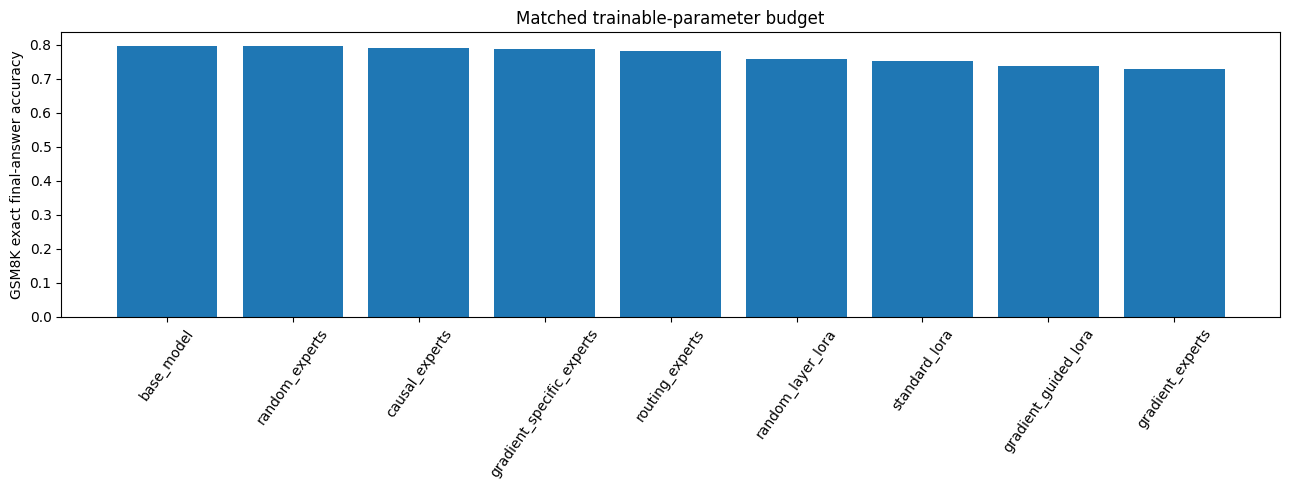

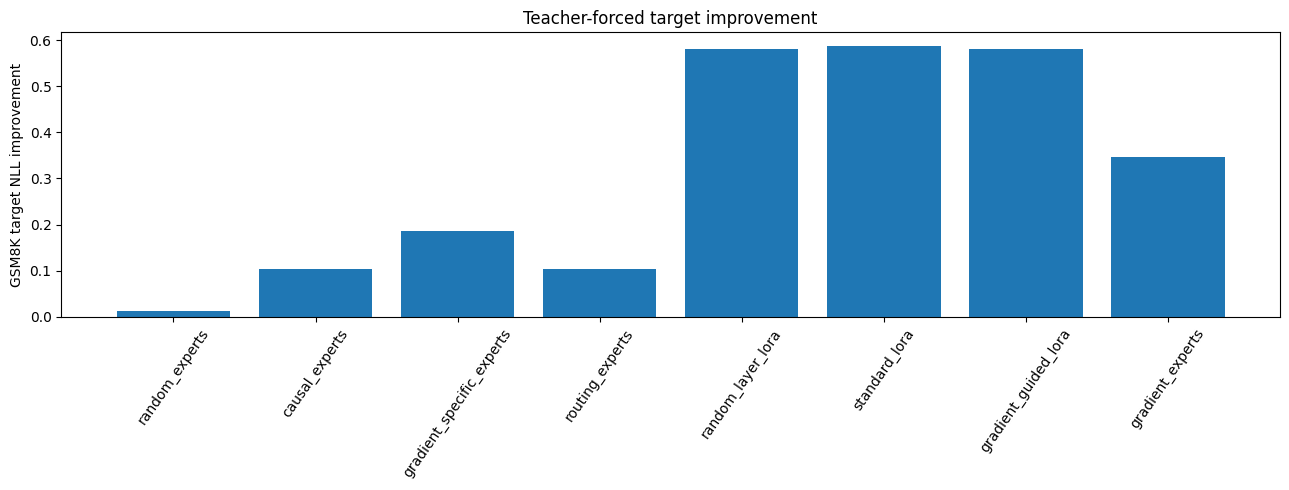

In [50]:
summary = (
    final_results.groupby(["method", "family"], as_index=False)
    .agg(
        n_runs=("order_seed", "count"),
        trainable_params=("trainable_params", "mean"),
        budget_rel_error=("budget_rel_error", "mean"),
        target_improvement_mean=("target_improvement", "mean"),
        target_improvement_std=("target_improvement", "std"),
        control_improvement_mean=("control_improvement", "mean"),
        specific_gain_mean=("specific_gain", "mean"),
        relative_target_improvement_mean=("relative_target_improvement", "mean"),
        relative_specific_gain_mean=("relative_specific_gain", "mean"),
        generation_accuracy_mean=("generation_accuracy", "mean"),
        generation_accuracy_std=("generation_accuracy", "std"),
        generation_accuracy_gain_mean=("generation_accuracy_gain", "mean"),
        peak_gpu_gib_mean=("peak_gpu_gib", "mean"),
        train_wall_seconds_mean=("train_wall_seconds", "mean"),
    )
    .sort_values(["generation_accuracy_mean", "target_improvement_mean"], ascending=False)
    .reset_index(drop=True)
)
atomic_to_csv(summary, RESULTS / "final_matched_summary.csv", index=False)
display(summary)

plot_df = pd.concat([
    pd.DataFrame([{
        "method": "base_model",
        "generation_accuracy_mean": BASE_GENERATION_ACCURACY,
        "target_improvement_mean": 0.0,
    }]),
    summary[["method", "generation_accuracy_mean", "target_improvement_mean"]],
], ignore_index=True)

fig, ax = plt.subplots(figsize=(13,5))
ax.bar(plot_df["method"], plot_df["generation_accuracy_mean"])
ax.set_ylabel("GSM8K exact final-answer accuracy")
ax.set_title("Matched trainable-parameter budget")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout(); fig.savefig(RESULTS / "gsm8k_accuracy_matched_budget.png", dpi=160); plt.show()

fig, ax = plt.subplots(figsize=(13,5))
ax.bar(summary["method"], summary["target_improvement_mean"])
ax.set_ylabel("GSM8K target NLL improvement")
ax.set_title("Teacher-forced target improvement")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout(); fig.savefig(RESULTS / "gsm8k_nll_improvement_matched_budget.png", dpi=160); plt.show()

## 39 — Automatic evidence report

In [51]:
winner = summary.iloc[0]
report = [
    "# Laguna XS.2 v9 matched-PEFT report",
    "",
    f"Protocol hash: `{PROTOCOL_HASH}`",
    f"Benchmark snapshot SHA256: `{SNAPSHOT_SHA256}`",
    "",
    "## Budget",
    "",
    f"Target trainable budget: {EXPERT_TARGET_PARAMS:,} parameters (K={EXPERT_BUDGET_K} full routed experts).",
    "",
    "## Base GSM8K",
    "",
    f"Untouched generation-subset accuracy: {BASE_GENERATION_ACCURACY:.4f} (n={len(final_generation_df)}).",
    "",
    "## Best matched method",
    "",
    (
        f"`{winner['method']}`: GSM8K exact accuracy {winner['generation_accuracy_mean']:.4f}, "
        f"accuracy gain {winner['generation_accuracy_gain_mean']:+.4f}, "
        f"target NLL improvement {winner['target_improvement_mean']:+.4f}."
    ),
    "",
    "## Full table",
    "",
    summary.to_markdown(index=False),
    "",
    "## Interpretation guardrails",
    "",
    "- Final test was not used for expert/LoRA location selection or LR tuning.",
    "- Standard broad LoRA alone selected one validation LR; all final LoRA location arms share it.",
    "- Expert arms use the v6-v8 established 1e-5 LR, giving LoRA the benefit of a validation LR sweep.",
    "- Expert primary metrics are from the physically merged native BF16 Laguna fused expert kernel.",
    "- MBPP is a teacher-forced collateral-damage control here; this notebook does not claim MBPP execution accuracy.",
]
for name in ["gradient_experts", "gradient_specific_experts", "standard_lora", "gradient_guided_lora"]:
    row = summary[summary.method == name]
    if not row.empty:
        r = row.iloc[0]
        report += [
            "",
            f"### {name}",
            f"Accuracy {r['generation_accuracy_mean']:.4f}; target improvement {r['target_improvement_mean']:+.4f}; specific gain {r['specific_gain_mean']:+.4f}.",
        ]
REPORT_PATH = RESULTS / "v9_evidence_report.md"
atomic_write_text(REPORT_PATH, "\n".join(report))
print("\n".join(report[:24]))
print("Full report:", REPORT_PATH)

# Laguna XS.2 v9 matched-PEFT report

Protocol hash: `792fd9d4a19c5f37`
Benchmark snapshot SHA256: `8cedb762f6d18ef0dc2f3a828bae64d68da03643238aa2659d93a65a289e361b`

## Budget

Target trainable budget: 12,582,912 parameters (K=4 full routed experts).

## Base GSM8K

Untouched generation-subset accuracy: 0.7969 (n=128).

## Best matched method

`random_experts`: GSM8K exact accuracy 0.7969, accuracy gain +0.0000, target NLL improvement +0.0126.

## Full table

| method                    | family      |   n_runs |   trainable_params |   budget_rel_error |   target_improvement_mean |   target_improvement_std |   control_improvement_mean |   specific_gain_mean |   relative_target_improvement_mean |   relative_specific_gain_mean |   generation_accuracy_mean |   generation_accuracy_std |   generation_accuracy_gain_mean |   peak_gpu_gib_mean |   train_wall_seconds_mean |
|:--------------------------|:------------|---------:|-------------------:|-------------------:|-------------------------

## 40 — Manifest, archive and final validity checklist

In [52]:
required_files = [
    "benchmark_snapshot.csv",
    "benchmark_snapshot_manifest.json",
    "protocol_config.json",
    "global_routing_screen.csv",
    "global_gradient_screen.csv",
    "attention_gradient_layer_screen.csv",
    "layer_causal_scores.csv",
    "hierarchical_group_history.csv",
    "hierarchical_individual_causal.csv",
    "greedy_causal_order.csv",
    "selection_only_rankings.json",
    "selection_only_selector_metrics.csv",
    "selection_precise_selector_metrics.csv",
    "frozen_expert_selectors.json",
    "lora_budget_plan.json",
    "lora_lr_sweep.csv",
    "chosen_lora_lr.json",
    "FROZEN_BEFORE_FINAL_TEST.json",
    "final_base_detail.npz",
    "base_gsm8k_generation.csv",
    "final_matched_results.csv",
    "final_matched_summary.csv",
    "v9_evidence_report.md",
]
missing = [name for name in required_files if not (RESULTS / name).exists()]
if missing:
    raise RuntimeError("Missing required result files: " + repr(missing))

check = pd.read_csv(RESULTS / "final_matched_results.csv")
expected_methods = {
    "random_experts", "routing_experts", "causal_experts",
    "gradient_experts", "gradient_specific_experts",
    "standard_lora", "random_layer_lora", "gradient_guided_lora",
}
if set(check.method) != expected_methods:
    raise RuntimeError("Final method coverage mismatch.")
counts = check.groupby("method")["order_seed"].nunique()
if not bool((counts == len(FINAL_ORDER_SEEDS)).all()):
    raise RuntimeError("One or more methods are missing final seeds.")
if check.trainable_params.le(0).any():
    raise RuntimeError("A final arm has zero trainable parameters.")
budget_errors = abs(check.trainable_params - EXPERT_TARGET_PARAMS) / float(EXPERT_TARGET_PARAMS)
if (budget_errors > MAX_LORA_BUDGET_REL_ERROR).any():
    bad = check.loc[budget_errors > MAX_LORA_BUDGET_REL_ERROR, ["method", "trainable_params"]]
    raise RuntimeError("Matched-budget violation:\n" + bad.to_string(index=False))
if not bool(np.isfinite(check[["target_improvement", "control_improvement", "generation_accuracy"]].to_numpy(dtype=np.float64)).all()):
    raise RuntimeError("Non-finite final result metric.")
if not (RESULTS / "FROZEN_BEFORE_FINAL_TEST.json").exists():
    raise RuntimeError("Frozen-before-final decision file missing.")

# Every checkpointed final row must have its associated generation/history files.
for r in check.itertuples(index=False):
    for stem in ["generation", "train_history"]:
        path = RESULTS / f"{stem}_{r.method}_seed{int(r.order_seed)}.csv"
        if not path.exists():
            raise RuntimeError(f"Missing per-run artifact: {path.name}")

manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "protocol_version": PROTOCOL_VERSION,
    "protocol_hash": PROTOCOL_HASH,
    "snapshot_sha256": SNAPSHOT_SHA256,
    "model_id": MODEL_ID,
    "transformers": package_version("transformers"),
    "peft": package_version("peft"),
    "torch": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "expert_target_params": EXPERT_TARGET_PARAMS,
    "methods": sorted(expected_methods),
    "final_seeds": FINAL_ORDER_SEEDS,
    "files": {name: sha256_file(RESULTS / name) for name in required_files},
}
atomic_write_text(RESULTS / "manifest.json", json.dumps(manifest, indent=2))

archive_path = RESULTS / "laguna_xs2_v9_matched_peft_results.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(RESULTS.iterdir()):
        if path.is_file() and path != archive_path:
            archive.write(path, arcname=path.name)

print("V9 VALIDITY CHECKLIST: PASS")
print("Results archive:", archive_path)

V9 VALIDITY CHECKLIST: PASS
Results archive: /home/ec2-user/workspace/laguna_xs2_v9_matched_peft_gsm8k/laguna_xs2_v9_matched_peft_results.zip
